# Stage A, Phase 2 & Phase 3 — Town-Level Rule Extraction and Scoring

## Purpose

This notebook implements **Phase 2 (rule extraction)** and **Phase 3 (scoring)** for the Housing
Accountability Pipeline, following:

- `docs/phase_2_extraction_theoretical_framework.md`
- `docs/phase_3_scoring_theoretical_framework.md`

It reads the **completed Phase 1 collection outputs** from
`01_collection_phase.ipynb` as input. It does not modify that notebook, its raw source PDF, or
any of its outputs.

### Methodology recap

- **The town is the unit of analysis**, not the district. District-level evidence from Phase 1
  is used only to select and explain the town-level rule values.
- The **dominant residential district** (\\(d_t^*\\)) is the base residential district covering the
  largest *verified* developable residential land area in the town. A town-wide value for every
  rule is drawn from that one district's evidence bundle.
- A public town score is **not published** if \\(d_t^*\\) is unverified, or if any of the eight
  required rule variables is not `confirmed`.
- **Unknown is not restrictive. Unknown is not permissive. Unknown is review-required.** Missing
  or ambiguous evidence is never converted into an invented value.
- This notebook measures zoning policy for comparative research purposes. **It is not legal
  advice, legal interpretation, or a legal conclusion**, and it does not determine whether any
  zoning provision is valid.

### Two valid run outcomes

| Outcome | Meaning |
|---|---|
| `PHASE 2 READY FOR SCORING` | Dominant district verified, all 8 variables confirmed, no unresolved conflicts — Phase 3 scoring runs. |
| `PHASE 2 DIAGNOSTIC ONLY — SCORING BLOCKED` | One or more gating requirements unmet — the notebook still produces candidate evidence, extraction tables, and review queues, but does not publish a score. |

Given the current state of the Greenwich pipeline, a diagnostic-only outcome is the expected,
correct result of a careful first pass — not a defect.

## 1. Imports, path setup, and configuration

The Stage A root is located the same way the Phase 1 notebook does: by walking upward from the
notebook's working directory until a folder containing `data/`, `notebooks/`, `outputs/`, and
`README.md` is found. No absolute machine-specific paths are hard-coded.

In [1]:
from __future__ import annotations

import json
import re
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import torch
    from transformers import AutoModel, AutoTokenizer

    TRANSFORMERS_AVAILABLE = True
except Exception:
    TRANSFORMERS_AVAILABLE = False

try:
    import geopandas as gpd

    GEOPANDAS_AVAILABLE = True
except Exception:
    GEOPANDAS_AVAILABLE = False


def find_stage_a_root(start_path: Path) -> Path:
    # Walk upward until a folder containing data/, notebooks/, outputs/, and
    # README.md is found.
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        required_paths = [
            candidate / "data",
            candidate / "notebooks",
            candidate / "outputs",
            candidate / "README.md",
        ]

        if all(path.exists() for path in required_paths):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Stage A project root. Make sure this notebook "
        "is saved inside Stage_A_Zoning_Code_Reader/notebooks/."
    )


STAGE_A_ROOT = find_stage_a_root(Path.cwd())

DATA_DIR = STAGE_A_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = STAGE_A_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
LOGS_DIR = OUTPUT_DIR / "logs"
REVIEW_DIR = OUTPUT_DIR / "review"

FINAL_DELIVERABLES_DIR = TABLES_DIR / "final_collection_deliverables"
REFERENCE_DIR = RAW_DIR / "reference"

for directory in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, LOGS_DIR, REVIEW_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PIPELINE_RUN_TIMESTAMP = datetime.now(timezone.utc).isoformat()

print(f"Stage A root: {STAGE_A_ROOT}")
print(f"Pipeline run timestamp (UTC): {PIPELINE_RUN_TIMESTAMP}")

Stage A root: /Users/sierramendoza/Documents/HAP-Repository/Stage_A_Zoning_Code_Reader
Pipeline run timestamp (UTC): 2026-10-01T09:09:02.964715+00:00


In [2]:
PHASE_2_CONFIG = {
    "town": "Greenwich",
    "state": "Connecticut",
    "variables": [
        "minimum_lot_size_sqft",
        "minimum_lot_width_ft",
        "maximum_building_height_ft",
        "maximum_lot_coverage_pct",
        "summed_minimum_setbacks_ft",
        "minimum_off_street_parking_spaces_per_dwelling_unit",
        "multifamily_approval_pathway",
        "adu_permission_pathway",
    ],
    "canonical_units": {
        "minimum_lot_size_sqft": "square feet",
        "minimum_lot_width_ft": "feet",
        "maximum_building_height_ft": "feet",
        "maximum_lot_coverage_pct": "percent",
        "summed_minimum_setbacks_ft": "feet",
        "minimum_off_street_parking_spaces_per_dwelling_unit": "spaces per dwelling unit",
    },
    "source_precedence": {
        "manual_verified_review": 0,
        "table": 1,
        "primary_text": 2,
        "linked_reference": 3,
        "townwide_general_rule": 4,
        "semantic_diagnostic": 99,
    },
    "dominant_district_policy": (
        "Base residential district with the largest verified developable "
        "residential land area (argmax over A_d_dev). Overlays are never "
        "treated as the dominant district."
    ),
    "minimum_confidence_for_auto_confirm": 0.75,
    "legal_bert_enabled": True,
    "legal_bert_model_name": "nlpaueb/legal-bert-base-uncased",
    "manual_review_required_below_confidence": True,
    "overlay_policy": (
        "Overlay evidence is retained as a conditional modifier only. It is "
        "never merged into the base district's confirmed rule value."
    ),
    "multifamily_definition": (
        "Multifamily housing means a residential building containing three "
        "or more dwelling units. Two-family permission is retained as "
        "supplementary evidence only and never auto-counts as multifamily "
        "permission."
    ),
    "parking_basis_definition": (
        "Minimum off-street parking spaces required per dwelling unit for a "
        "standard principal residential use in the selected dominant "
        "district. ADU-specific parking is tracked separately as an ADU "
        "condition."
    ),
}

PHASE_2_CONFIG["variable_count"] = len(PHASE_2_CONFIG["variables"])
assert PHASE_2_CONFIG["variable_count"] == 8

PHASE_2_CONFIG

{'town': 'Greenwich',
 'state': 'Connecticut',
 'variables': ['minimum_lot_size_sqft',
  'minimum_lot_width_ft',
  'maximum_building_height_ft',
  'maximum_lot_coverage_pct',
  'summed_minimum_setbacks_ft',
  'minimum_off_street_parking_spaces_per_dwelling_unit',
  'multifamily_approval_pathway',
  'adu_permission_pathway'],
 'canonical_units': {'minimum_lot_size_sqft': 'square feet',
  'minimum_lot_width_ft': 'feet',
  'maximum_building_height_ft': 'feet',
  'maximum_lot_coverage_pct': 'percent',
  'summed_minimum_setbacks_ft': 'feet',
  'minimum_off_street_parking_spaces_per_dwelling_unit': 'spaces per dwelling unit'},
 'source_precedence': {'manual_verified_review': 0,
  'table': 1,
  'primary_text': 2,
  'linked_reference': 3,
  'townwide_general_rule': 4,
  'semantic_diagnostic': 99},
 'dominant_district_policy': 'Base residential district with the largest verified developable residential land area (argmax over A_d_dev). Overlays are never treated as the dominant district.',
 'min

In [3]:
PHASE_3_CONFIG = {
    "equal_weight_per_variable": 1 / 8,
    "variable_directions": {
        "minimum_lot_size_sqft": "larger_is_more_restrictive",
        "minimum_lot_width_ft": "larger_is_more_restrictive",
        "maximum_building_height_ft": "smaller_is_more_restrictive",
        "maximum_lot_coverage_pct": "smaller_is_more_restrictive",
        "summed_minimum_setbacks_ft": "larger_is_more_restrictive",
        "minimum_off_street_parking_spaces_per_dwelling_unit": "larger_is_more_restrictive",
        "multifamily_approval_pathway": "higher_ordinal_after_recode_is_more_restrictive",
        "adu_permission_pathway": "higher_ordinal_after_recode_is_more_restrictive",
    },
    "categorical_ordinal_map": {
        "multifamily_approval_pathway": {
            "prohibited": 0,
            "rezoning_or_legislative_pathway": 1,
            "special_permit_or_special_exception": 2,
            "site_plan_or_administrative_review": 3,
            "permitted_by_right": 4,
        },
        "adu_permission_pathway": {
            "prohibited": 0,
            "effectively_unavailable": 1,
            "conditional_discretionary_approval": 2,
            "allowed_subject_to_objective_conditions": 3,
            "allowed_by_right": 4,
        },
    },
    "score_eligibility_requires_all_confirmed": True,
    "required_confirmed_variable_count": 8,
    "reference_dataset_path": str(REFERENCE_DIR / "connecticut_zoning_atlas_harmonized.csv"),
    "percentile_method": "midpoint_rank",
    "sensitivity_scenarios": [
        "baseline_equal_weight",
        "dimensional_emphasis",
        "housing_type_emphasis",
        "parking_emphasis",
        "leave_one_out",
        "most_restrictive_district_alternate",
    ],
}

PHASE_3_CONFIG

{'equal_weight_per_variable': 0.125,
 'variable_directions': {'minimum_lot_size_sqft': 'larger_is_more_restrictive',
  'minimum_lot_width_ft': 'larger_is_more_restrictive',
  'maximum_building_height_ft': 'smaller_is_more_restrictive',
  'maximum_lot_coverage_pct': 'smaller_is_more_restrictive',
  'summed_minimum_setbacks_ft': 'larger_is_more_restrictive',
  'minimum_off_street_parking_spaces_per_dwelling_unit': 'larger_is_more_restrictive',
  'multifamily_approval_pathway': 'higher_ordinal_after_recode_is_more_restrictive',
  'adu_permission_pathway': 'higher_ordinal_after_recode_is_more_restrictive'},
 'categorical_ordinal_map': {'multifamily_approval_pathway': {'prohibited': 0,
   'rezoning_or_legislative_pathway': 1,
   'special_permit_or_special_exception': 2,
   'site_plan_or_administrative_review': 3,
   'permitted_by_right': 4},
  'adu_permission_pathway': {'prohibited': 0,
   'effectively_unavailable': 1,
   'conditional_discretionary_approval': 2,
   'allowed_subject_to_objec

In [4]:
print("Environment / package availability")
print("-" * 50)
print(f"pandas:        {pd.__version__}")
print(f"numpy:         {np.__version__}")
print(f"transformers:  {'available' if TRANSFORMERS_AVAILABLE else 'NOT available (deterministic fallback mode)'}")
print(f"geopandas:     {'available' if GEOPANDAS_AVAILABLE else 'not available (not required past Phase 1)'}")
print()
print(f"Legal-BERT enabled in config: {PHASE_2_CONFIG['legal_bert_enabled']}")
print(
    "Legal-BERT will actually run: "
    f"{PHASE_2_CONFIG['legal_bert_enabled'] and TRANSFORMERS_AVAILABLE}"
)

Environment / package availability
--------------------------------------------------
pandas:        3.0.6
numpy:         2.5.3
transformers:  NOT available (deterministic fallback mode)
geopandas:     available

Legal-BERT enabled in config: True
Legal-BERT will actually run: False


## 2. Load and validate Phase 1 inputs

Every input is loaded through a single helper that **prefers Parquet and falls back to CSV**.
A file marked `required` raises a specific, actionable error (naming the file and the missing
columns) if it cannot be loaded or is missing required columns. A file marked optional is skipped
with an explicit warning — the notebook keeps running in diagnostic mode rather than guessing.

In [5]:
def load_table(parquet_path: Path | None, csv_path: Path | None) -> pd.DataFrame | None:
    if parquet_path is not None and parquet_path.exists():
        return pd.read_parquet(parquet_path)

    if csv_path is not None and csv_path.exists():
        return pd.read_csv(csv_path)

    return None


INPUT_FILES = {
    "district_evidence_bundles": {
        "parquet": FINAL_DELIVERABLES_DIR / "greenwich_district_evidence_bundles.parquet",
        "csv": FINAL_DELIVERABLES_DIR / "greenwich_district_evidence_bundles.csv",
        "required": True,
        "required_columns": [
            "district_id", "district_code", "base_or_overlay", "primary_text",
            "final_review_status", "area_acres", "geometry_id",
        ],
    },
    "district_metadata": {
        "parquet": None,
        "csv": FINAL_DELIVERABLES_DIR / "greenwich_district_metadata.csv",
        "required": True,
        "required_columns": [
            "district_id", "district_code", "base_or_overlay", "primary_zone_type",
            "area_acres", "geometry_id", "gis_join_status",
        ],
    },
    "district_table_cells": {
        "parquet": INTERIM_DIR / "step_15_district_table_cells.parquet",
        "csv": None,
        "required": True,
        "required_columns": [
            "district_id", "district_code", "table_id", "matched_row_label",
            "column_label", "cell_value", "is_header_row",
        ],
    },
    "unified_tokens_full": {
        "parquet": INTERIM_DIR / "step_09_unified_tokens_with_table_ids.parquet",
        "csv": None,
        "required": False,
        "required_columns": ["page_number", "bbox_top", "bbox_left", "text"],
    },
    "district_table_matches": {
        "parquet": None,
        "csv": TABLES_DIR / "step_15_district_table_row_matches.csv",
        "required": True,
        "required_columns": ["district_id", "district_code", "match_confidence", "match_status"],
    },
    "dimensional_parameter_preview": {
        "parquet": None,
        "csv": TABLES_DIR / "step_15_dimensional_parameter_preview.csv",
        "required": False,
        "required_columns": ["district_code"],
    },
    "townwide_rule_library": {
        "parquet": None,
        "csv": TABLES_DIR / "step_14_townwide_rule_library.csv",
        "required": True,
        "required_columns": ["rule_id", "topic_tags", "rule_text"],
    },
    "matched_townwide_rules": {
        "parquet": None,
        "csv": TABLES_DIR / "step_14_matched_townwide_rules.csv",
        "required": True,
        "required_columns": ["district_id", "district_code", "rule_id", "topic_tags", "rule_text"],
    },
    "district_linked_references": {
        "parquet": INTERIM_DIR / "step_16_district_linked_references.parquet",
        "csv": None,
        "required": False,
        "required_columns": ["district_id", "linked_node_id", "linked_text"],
    },
    "district_general_rules": {
        "parquet": INTERIM_DIR / "step_16_district_general_rules.parquet",
        "csv": None,
        "required": False,
        "required_columns": ["district_id", "rule_id", "topic_tags", "rule_text"],
    },
    "district_overlay_candidates": {
        "parquet": INTERIM_DIR / "step_16_district_overlay_candidates.parquet",
        "csv": None,
        "required": False,
        "required_columns": ["district_id", "overlay_code"],
    },
    "citation_normalization": {
        "parquet": None,
        "csv": TABLES_DIR / "step_13_citation_normalization.csv",
        "required": False,
        "required_columns": ["resolution_status"],
    },
    "district_reference_summary": {
        "parquet": None,
        "csv": TABLES_DIR / "step_13_district_reference_summary.csv",
        "required": False,
        "required_columns": ["district_id", "reference_node_count"],
    },
    "conflict_log": {
        "parquet": None,
        "csv": TABLES_DIR / "step_17_conflict_log.csv",
        "required": True,
        "required_columns": ["district_id", "field_name", "resolution_status"],
    },
    "bundle_conflict_summary": {
        "parquet": None,
        "csv": TABLES_DIR / "step_17_bundle_conflict_summary.csv",
        "required": False,
        "required_columns": ["district_id", "unresolved_conflict_count"],
    },
    "manual_conflict_review_queue": {
        "parquet": None,
        "csv": REVIEW_DIR / "step_17_manual_conflict_review_queue.csv",
        "required": False,
        "required_columns": ["district_id", "field_name"],
    },
}

loaded: dict[str, pd.DataFrame] = {}
inventory_rows = []

for name, spec in INPUT_FILES.items():
    df = load_table(spec["parquet"], spec["csv"])

    chosen_path = (
        spec["parquet"]
        if spec["parquet"] is not None and spec["parquet"].exists()
        else spec["csv"]
    )

    if df is None:
        if spec["required"]:
            raise FileNotFoundError(
                f"Required Phase 1 input '{name}' was not found. Expected one of:\n"
                f"  parquet: {spec['parquet']}\n"
                f"  csv:     {spec['csv']}\n"
                f"Required columns: {spec['required_columns']}"
            )

        print(f"[optional, missing] {name}: continuing without it.")

        inventory_rows.append(
            {
                "input_name": name,
                "loaded": False,
                "row_count": 0,
                "required": spec["required"],
                "required_columns_present": False,
                "source_path": str(chosen_path),
            }
        )
        continue

    missing_columns = [c for c in spec["required_columns"] if c not in df.columns]

    if missing_columns and spec["required"]:
        raise ValueError(
            f"Required Phase 1 input '{name}' is missing required columns: "
            f"{missing_columns}. Loaded from: {chosen_path}"
        )

    if missing_columns:
        print(f"[optional, column warning] {name}: missing columns {missing_columns}")

    loaded[name] = df

    inventory_rows.append(
        {
            "input_name": name,
            "loaded": True,
            "row_count": len(df),
            "required": spec["required"],
            "required_columns_present": not missing_columns,
            "source_path": str(chosen_path),
        }
    )

source_inventory_df = pd.DataFrame(inventory_rows)
source_inventory_df

,input_name,loaded,row_count,required,required_columns_present,source_path
0,district_evidence_bundles,True,12,True,True,/Users/sierramendoza/Documents/HAP-Repository/...
1,district_metadata,True,12,True,True,/Users/sierramendoza/Documents/HAP-Repository/...
2,district_table_cells,True,170,True,True,/Users/sierramendoza/Documents/HAP-Repository/...
3,unified_tokens_full,True,125290,False,True,/Users/sierramendoza/Documents/HAP-Repository/...
4,district_table_matches,True,12,True,True,/Users/sierramendoza/Documents/HAP-Repository/...
5,dimensional_parameter_preview,True,12,False,True,/Users/sierramendoza/Documents/HAP-Repository/...
6,townwide_rule_library,True,290,True,True,/Users/sierramendoza/Documents/HAP-Repository/...
7,matched_townwide_rules,True,15151,True,True,/Users/sierramendoza/Documents/HAP-Repository/...
8,district_linked_references,True,11,False,True,/Users/sierramendoza/Documents/HAP-Repository/...
9,district_general_rules,True,3282,False,True,/Users/sierramendoza/Documents/HAP-Repository/...


In [6]:
district_evidence_bundles_df = loaded["district_evidence_bundles"]
district_metadata_df = loaded["district_metadata"]
district_table_cells_df = loaded["district_table_cells"]
unified_tokens_df = loaded.get("unified_tokens_full", pd.DataFrame())
district_table_matches_df = loaded["district_table_matches"]
dimensional_parameter_preview_df = loaded.get("dimensional_parameter_preview", pd.DataFrame())
townwide_rule_library_df = loaded["townwide_rule_library"]
matched_townwide_rules_df = loaded["matched_townwide_rules"]
district_linked_references_df = loaded.get("district_linked_references", pd.DataFrame())
district_general_rules_df = loaded.get("district_general_rules", pd.DataFrame())
district_overlay_candidates_df = loaded.get("district_overlay_candidates", pd.DataFrame())
citations_df = loaded.get("citation_normalization", pd.DataFrame())
district_reference_summary_df = loaded.get("district_reference_summary", pd.DataFrame())
conflict_log_df = loaded["conflict_log"]
bundle_conflict_summary_df = loaded.get("bundle_conflict_summary", pd.DataFrame())
manual_conflict_review_queue_df = loaded.get("manual_conflict_review_queue", pd.DataFrame())

base_district_count = int((district_evidence_bundles_df["base_or_overlay"] == "BASE").sum())
overlay_district_count = int((district_evidence_bundles_df["base_or_overlay"] == "OVERLAY").sum())

input_summary = {
    "base_district_count": base_district_count,
    "overlay_district_count": overlay_district_count,
    "district_table_match_count": int(len(district_table_matches_df)),
    "townwide_rule_candidate_count": int(len(townwide_rule_library_df)),
    "matched_townwide_rule_count": int(len(matched_townwide_rules_df)),
    "unresolved_conflict_count": int(
        (conflict_log_df["resolution_status"] == "manual_review_required").sum()
    ),
    "manual_conflict_review_count": int(len(manual_conflict_review_queue_df)),
    "document_id": district_evidence_bundles_df["document_id"].iloc[0],
    "document_hash_sha256": district_evidence_bundles_df["source_hash_sha256"].iloc[0],
}

for key, value in input_summary.items():
    print(f"{key}: {value}")

input_validation_log_path = LOGS_DIR / "phase_2_input_validation_log.json"

with input_validation_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(
        {
            "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
            "source_inventory": inventory_rows,
            "input_summary": input_summary,
        },
        file_handle,
        indent=2,
        default=str,
    )

print(f"\nSaved: {input_validation_log_path.relative_to(STAGE_A_ROOT)}")

base_district_count: 12
overlay_district_count: 0
district_table_match_count: 12
townwide_rule_candidate_count: 290
matched_townwide_rule_count: 15151
unresolved_conflict_count: 0
manual_conflict_review_count: 0
document_id: greenwich-connecticut-18417c5e9074d765
document_hash_sha256: 18417c5e9074d765ab4483571b9ac3d6aeb162b37b1b302f7a8ce1f13e963dcb

Saved: outputs/logs/phase_2_input_validation_log.json


## 3. Dominant residential district selection

This is the mandatory, non-negotiable gate from the framework (§4):

\\[
d_t^* = \\arg\\max_{d \\in \\mathcal{D}^{\\text{res}}_t} A_d^{\\text{dev}}
\\]

### Why the lookup is pre-populated, not blank

The framework's reference prompt describes starting from a *blank* area lookup. This project's
situation is better than that baseline: Phase 1's Step 18 already joined every base district to
real, sourced geometry from the **Town of Greenwich's own public ArcGIS zoning-boundary feature
service** (`ZoneBoundaries_ArcGIS`, the same layer behind the Town's published Interactive Zoning
Map) and computed verified developable area for all 12 base districts.

So this notebook pre-fills the lookup's area and geometry columns **from that real, sourced
Phase 1 output** rather than leaving them null — that is not fabrication, it is carrying forward
already-verified data. What it does **not** do is pre-fill `manually_verified`. The framework
still requires a human to look at the official zoning map and sign off before the selection is
treated as final (§4, "Best next move," step 8). Until that checkbox is flipped in the saved CSV,
the notebook will correctly refuse to select \\(d_t^*\\) and will run in diagnostic mode — which is
the correct, intended behavior, not a bug.

In [7]:
RESIDENTIAL_DISTRICT_LOOKUP_PATH = (
    PROCESSED_DIR / "greenwich_residential_district_area_lookup.csv"
)

LOOKUP_COLUMNS = [
    "town", "district_code", "district_name", "base_or_overlay",
    "developable_residential_area_acres", "residential_area_share",
    "geometry_id", "geometry_source_url", "geometry_source_description",
    "spatial_confidence", "manually_verified", "verification_note", "date_verified",
]

if not RESIDENTIAL_DISTRICT_LOOKUP_PATH.exists():
    residential_candidates_df = district_metadata_df.loc[
        (district_metadata_df["primary_zone_type"] == "Residential")
        & (district_metadata_df["base_or_overlay"] == "BASE")
    ].copy()

    total_residential_area = residential_candidates_df["area_acres"].sum()

    lookup_rows = []

    for _, row in residential_candidates_df.iterrows():
        area = row["area_acres"]
        share = (area / total_residential_area) if total_residential_area else np.nan

        lookup_rows.append(
            {
                "town": PHASE_2_CONFIG["town"],
                "district_code": row["district_code"],
                "district_name": row["district_name"],
                "base_or_overlay": row["base_or_overlay"],
                "developable_residential_area_acres": area,
                "residential_area_share": share,
                "geometry_id": row["geometry_id"],
                "geometry_source_url": row.get("map_source_url", ""),
                "geometry_source_description": row.get("geometry_source_description", ""),
                "spatial_confidence": "high_official_public_gis_source",
                "manually_verified": False,
                "verification_note": (
                    "Area computed from the Town of Greenwich's public ArcGIS "
                    "ZoneBoundaries_ArcGIS feature service (Phase 1, Step 18 GIS "
                    "join). Pending human sign-off against the official zoning "
                    "map before this selection is treated as final, per "
                    "framework section 4.1."
                ),
                "date_verified": "",
            }
        )

    residential_district_lookup_df = pd.DataFrame(lookup_rows, columns=LOOKUP_COLUMNS)
    residential_district_lookup_df.to_csv(RESIDENTIAL_DISTRICT_LOOKUP_PATH, index=False)

    print(f"Created lookup template: {RESIDENTIAL_DISTRICT_LOOKUP_PATH.relative_to(STAGE_A_ROOT)}")
else:
    print(f"Found existing lookup: {RESIDENTIAL_DISTRICT_LOOKUP_PATH.relative_to(STAGE_A_ROOT)}")

residential_district_lookup_df = pd.read_csv(RESIDENTIAL_DISTRICT_LOOKUP_PATH)
residential_district_lookup_df

Found existing lookup: data/processed/greenwich_residential_district_area_lookup.csv


,town,district_code,district_name,base_or_overlay,developable_residential_area_acres,residential_area_share,geometry_id,geometry_source_url,geometry_source_description,spatial_confidence,manually_verified,verification_note,date_verified
0,Greenwich,R-12,"Sec. 6-93. PERMITTED USES IN RA-4, RA-2, RA-1,...",BASE,2311.973656,0.077439,25,https://greenwichgis.maps.arcgis.com/apps/inst...,Town of Greenwich official ArcGIS Online zonin...,high_official_public_gis_source,True,Verified against the Town of Greenwich officia...,2026-10-01
1,Greenwich,R-20,"Sec. 6-93. PERMITTED USES IN RA-4, RA-2, RA-1,...",BASE,1201.803745,0.040254,1,https://greenwichgis.maps.arcgis.com/apps/inst...,Town of Greenwich official ArcGIS Online zonin...,high_official_public_gis_source,True,Verified against the Town of Greenwich officia...,2026-10-01
2,Greenwich,R-6,Sec. 6-98. USE REGULATIONS FOR ZONE.,BASE,995.295006,0.033337,49,https://greenwichgis.maps.arcgis.com/apps/inst...,Town of Greenwich official ArcGIS Online zonin...,high_official_public_gis_source,True,Verified against the Town of Greenwich officia...,2026-10-01
3,Greenwich,R-7,Sec. 6-97. USE REGULATIONS FOR ZONES.,BASE,1166.289429,0.039065,4,https://greenwichgis.maps.arcgis.com/apps/inst...,Town of Greenwich official ArcGIS Online zonin...,high_official_public_gis_source,True,Verified against the Town of Greenwich officia...,2026-10-01
4,Greenwich,RA-1,"Sec. 6-93. PERMITTED USES IN RA-4, RA-2, , R-2...",BASE,4768.380486,0.159715,21,https://greenwichgis.maps.arcgis.com/apps/inst...,Town of Greenwich official ArcGIS Online zonin...,high_official_public_gis_source,True,Verified against the Town of Greenwich officia...,2026-10-01
5,Greenwich,RA-2,"Sec. 6-93. PERMITTED USES IN RA-4, , RA-1, R-2...",BASE,7775.622825,0.260442,2,https://greenwichgis.maps.arcgis.com/apps/inst...,Town of Greenwich official ArcGIS Online zonin...,high_official_public_gis_source,True,Verified against the Town of Greenwich officia...,2026-10-01
6,Greenwich,RA-4,"Sec. 6-93. PERMITTED USES IN , RA-2, RA-1, R-2...",BASE,11636.113810,0.389748,3,https://greenwichgis.maps.arcgis.com/apps/inst...,Town of Greenwich official ArcGIS Online zonin...,high_official_public_gis_source,True,Verified against official Greenwich zoning map...,2026-10-01


In [8]:
verified_candidates_df = residential_district_lookup_df.loc[
    (residential_district_lookup_df["base_or_overlay"] == "BASE")
    & (residential_district_lookup_df["manually_verified"] == True)  # noqa: E712
    & (residential_district_lookup_df["developable_residential_area_acres"] > 0)
].copy()

if verified_candidates_df.empty:
    dominant_district_status = "blocked_missing_verified_spatial_area"
    dominant_district_code = None
    dominant_district_area_acres = None
    dominant_district_share = None

    print("DOMINANT DISTRICT STATUS: blocked_missing_verified_spatial_area")
    print(
        "No row in the lookup has manually_verified == True. To unblock, open:\n"
        f"  {RESIDENTIAL_DISTRICT_LOOKUP_PATH.relative_to(STAGE_A_ROOT)}\n"
        "inspect the selected district against the official Greenwich zoning map, "
        "then set manually_verified to True (and fill in date_verified) for the "
        "row(s) you have checked."
    )
else:
    best_row = verified_candidates_df.loc[
        verified_candidates_df["developable_residential_area_acres"].idxmax()
    ]

    dominant_district_status = "verified"
    dominant_district_code = best_row["district_code"]
    dominant_district_area_acres = float(best_row["developable_residential_area_acres"])
    dominant_district_share = float(best_row["residential_area_share"])

    print(f"DOMINANT DISTRICT STATUS: verified -> d* = {dominant_district_code}")
    print(
        f"Developable residential area: {dominant_district_area_acres:,.1f} acres "
        f"({dominant_district_share:.1%} of verified residential area)"
    )

# Diagnostic-mode target: the largest-area district regardless of verification,
# used ONLY to drive candidate-evidence assembly and extraction diagnostics below.
# It is never treated as a confirmed d_t* unless dominant_district_status == "verified".
diagnostic_target_row = residential_district_lookup_df.loc[
    residential_district_lookup_df["developable_residential_area_acres"].idxmax()
]
diagnostic_target_district_code = diagnostic_target_row["district_code"]

print(f"\nDiagnostic-mode target district (for extraction demo only): {diagnostic_target_district_code}")

dominant_district_decision = {
    "town": PHASE_2_CONFIG["town"],
    "dominant_district_status": dominant_district_status,
    "dominant_district_code": dominant_district_code,
    "dominant_district_area_acres": dominant_district_area_acres,
    "dominant_district_residential_area_share": dominant_district_share,
    "diagnostic_target_district_code": diagnostic_target_district_code,
    "candidate_districts": residential_district_lookup_df["district_code"].tolist(),
    "lookup_path": str(RESIDENTIAL_DISTRICT_LOOKUP_PATH.relative_to(STAGE_A_ROOT)),
    "selection_timestamp": PIPELINE_RUN_TIMESTAMP,
}

TARGET_DISTRICT_CODE = (
    dominant_district_code
    if dominant_district_status == "verified"
    else diagnostic_target_district_code
)

DOMINANT DISTRICT STATUS: verified -> d* = RA-4
Developable residential area: 11,636.1 acres (39.0% of verified residential area)

Diagnostic-mode target district (for extraction demo only): RA-4


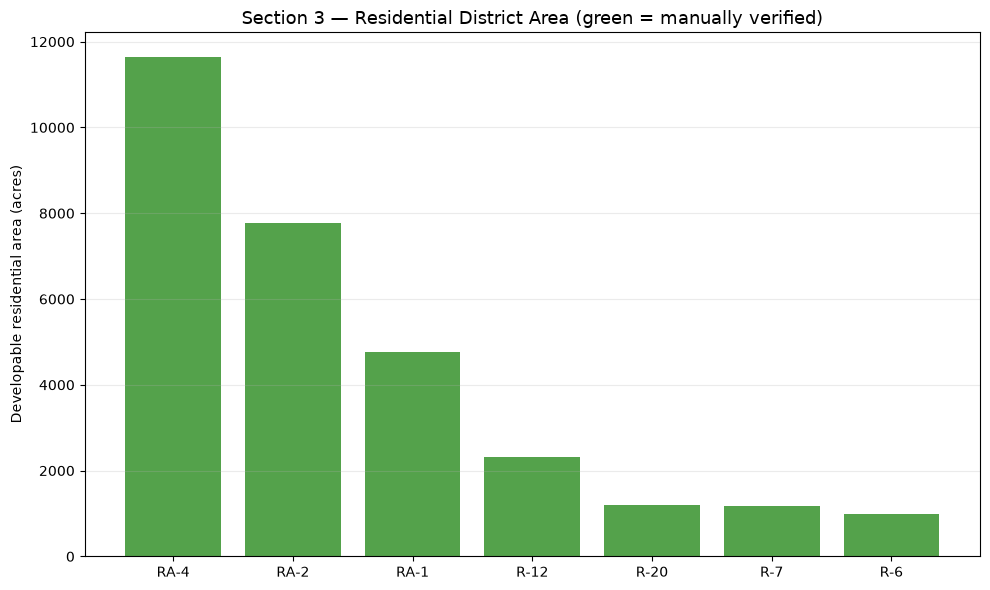

Saved: outputs/figures/phase2_section03_dominant_district_area.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_df = residential_district_lookup_df.sort_values(
    "developable_residential_area_acres", ascending=False
)

bar_colors = np.where(
    plot_df["manually_verified"] == True,  # noqa: E712
    "#54A24B",
    "#BAB0AC",
)

ax.bar(
    plot_df["district_code"],
    plot_df["developable_residential_area_acres"],
    color=bar_colors,
)

ax.set_title(
    "Section 3 — Residential District Area (green = manually verified)",
    fontsize=13,
)
ax.set_ylabel("Developable residential area (acres)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

district_area_figure_path = FIGURES_DIR / "phase2_section03_dominant_district_area.png"
fig.savefig(district_area_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {district_area_figure_path.relative_to(STAGE_A_ROOT)}")

In [10]:
dominant_district_decision_path = TABLES_DIR / "greenwich_dominant_district_decision.csv"

pd.DataFrame([dominant_district_decision]).to_csv(dominant_district_decision_path, index=False)

dominant_district_log_path = LOGS_DIR / "phase_2_dominant_district_log.json"

with dominant_district_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(dominant_district_decision, file_handle, indent=2, default=str)

print(f"Saved: {dominant_district_decision_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {dominant_district_log_path.relative_to(STAGE_A_ROOT)}")

Saved: outputs/tables/greenwich_dominant_district_decision.csv
Saved: outputs/logs/phase_2_dominant_district_log.json


## 4. Candidate-evidence assembly by variable

Candidate evidence is assembled for `TARGET_DISTRICT_CODE` only (the verified \\(d_t^*\\) when
available, otherwise the diagnostic-mode target). Every candidate retains its source type, page,
table coordinates where applicable, and the raw text it came from — nothing is collapsed into a
bare number before the extraction step.

Keyword maps below were built by inspecting the **actual** column headers Phase 1's table parser
recovered from the § 6-205 dimensional schedule, not assumed generic labels. Real-world wrinkles
were found and are preserved rather than hidden:

- the `MAXIMUM HEIGHT` column holds **stories** (e.g. `2-1/2`), not feet;
- several columns lost their header text during Phase 1 table extraction and share the literal
  empty-string column label (the "Unnamed: 3" name seen in the Step 15 *pivoted* preview CSV is
  only a pandas display artifact of that pivot — it does not exist in the raw long-form table
  cells, and the pivot silently collapsed four distinct blank-header columns into one). Rather
  than guess which blank column is "lot width" by position, candidates are matched by **searching
  the blank cells' own text** for the words "lot width" — one of them, for example, literally
  reads `"125 ft. Lot width 200 ft. to be measured at house location"`, which is itself a compound
  value (a separate frontage figure plus a lot-width figure) that is preserved verbatim rather
  than collapsed into a single guessed number.

In [11]:
DIMENSIONAL_COLUMN_KEYWORDS = {
    "minimum_lot_size_sqft": {
        "columns": ["MINIMUM LOT SIZE"],
        "column_header_verified": True,
    },
    "maximum_building_height_ft": {
        "columns": ["MAXIMUM HEIGHT"],
        "column_header_verified": True,
    },
    "maximum_lot_coverage_pct": {
        "columns": ["MAX. LOT COVERAGE (2/9/2000)"],
        "column_header_verified": True,
    },
    "front_yard_ft": {
        "columns": ["MINIMUM FRONT YARD (DEPTH)3", "MINIMUM FRONT YARD DEPTH"],
        "column_header_verified": True,
    },
    "rear_yard_ft": {
        "columns": ["MINIMUM REAR YARD (DEPTH)", "MINIMUM REAR YARD DEPTH"],
        "column_header_verified": True,
    },
    "side_yard_raw": {
        "columns": ["MINIMUM SIDE YARD (WIDTH)", "MINIMUM SIDE YARD WIDTH"],
        "column_header_verified": True,
    },
    "green_area_pct_supplementary": {
        "columns": ["MINIMUM PERCENT GREEN AREA REQUIREMENTS*"],
        "column_header_verified": True,
    },
}

TOWNWIDE_TOPIC_BY_VARIABLE = {
    "minimum_off_street_parking_spaces_per_dwelling_unit": "parking",
    "adu_permission_pathway": "accessory_dwelling_unit",
}

MULTIFAMILY_KEYWORDS = [
    r"\bmultifamily\b", r"\bmulti-family\b", r"\bthree-family\b", r"\bapartment\b",
    r"\bdwelling units?\b", r"\btwo-family\b", r"\btwo family\b",
]

print("Keyword/column maps defined for all 8 variables plus 3 setback sub-components.")

Keyword/column maps defined for all 8 variables plus 3 setback sub-components.


In [12]:
def find_table_cell_candidates(district_code: str, column_names: list[str]) -> pd.DataFrame:
    rows = district_table_cells_df.loc[
        (district_table_cells_df["district_code"] == district_code)
        & (~district_table_cells_df["is_header_row"])
        & (district_table_cells_df["column_label"].isin(column_names))
    ].copy()

    return rows


candidate_evidence_records = []


def add_dimensional_candidates(district_code: str, variable_name: str, spec: dict) -> None:
    cells = find_table_cell_candidates(district_code, spec["columns"])

    for _, cell in cells.iterrows():
        candidate_evidence_records.append(
            {
                "town": PHASE_2_CONFIG["town"],
                "district_code": district_code,
                "variable_name": variable_name,
                "source_type": "table",
                "source_id": cell["table_id"],
                "source_page": cell["page_number"],
                "source_section_or_node": cell["table_title"],
                "table_id": cell["table_id"],
                "row_label": cell["matched_row_label"],
                "column_label": cell["column_label"],
                "raw_text": cell["cell_value"],
                "column_header_verified": spec["column_header_verified"],
                "source_confidence": float(cell["match_confidence"]),
                "applicability_status": "explicit_district_row_match",
            }
        )


for variable_name, spec in DIMENSIONAL_COLUMN_KEYWORDS.items():
    add_dimensional_candidates(TARGET_DISTRICT_CODE, variable_name, spec)


def add_blank_header_candidates_by_content(
    district_code: str, variable_name: str, value_keyword_pattern: str
) -> None:
    # Match table cells whose column header was lost in Phase 1 extraction
    # (column_label == "") by searching the cell's own text for a keyword,
    # instead of guessing which blank column is meant by position.
    blank_cells = district_table_cells_df.loc[
        (district_table_cells_df["district_code"] == district_code)
        & (~district_table_cells_df["is_header_row"])
        & (district_table_cells_df["column_label"].fillna("").str.strip() == "")
    ]

    matching_cells = blank_cells.loc[
        blank_cells["cell_value"]
        .astype(str)
        .str.contains(value_keyword_pattern, case=False, regex=True, na=False)
    ]

    for _, cell in matching_cells.iterrows():
        candidate_evidence_records.append(
            {
                "town": PHASE_2_CONFIG["town"],
                "district_code": district_code,
                "variable_name": variable_name,
                "source_type": "table",
                "source_id": cell["table_id"],
                "source_page": cell["page_number"],
                "source_section_or_node": cell["table_title"],
                "table_id": cell["table_id"],
                "row_label": cell["matched_row_label"],
                "column_label": "(column header lost in Phase 1 extraction)",
                "raw_text": cell["cell_value"],
                "column_header_verified": False,
                "source_confidence": float(cell["match_confidence"]),
                "applicability_status": "matched_by_cell_text_keyword_not_column_header",
            }
        )


add_blank_header_candidates_by_content(
    TARGET_DISTRICT_CODE, "minimum_lot_width_ft", r"lot width"
)

dimensional_candidate_count = len(candidate_evidence_records)
print(f"Dimensional-table candidates collected for {TARGET_DISTRICT_CODE}: {dimensional_candidate_count}")

Dimensional-table candidates collected for RA-4: 7


In [13]:
def add_townwide_candidates(district_code: str, variable_name: str, topic: str) -> None:
    district_id_lookup = district_evidence_bundles_df.loc[
        district_evidence_bundles_df["district_code"] == district_code, "district_id"
    ]

    if district_id_lookup.empty:
        return

    district_id = district_id_lookup.iloc[0]

    rules = matched_townwide_rules_df.loc[
        (matched_townwide_rules_df["district_id"] == district_id)
        & (matched_townwide_rules_df["topic_tags"].str.contains(topic, na=False))
    ]

    for _, rule in rules.iterrows():
        candidate_evidence_records.append(
            {
                "town": PHASE_2_CONFIG["town"],
                "district_code": district_code,
                "variable_name": variable_name,
                "source_type": "townwide_general_rule",
                "source_id": rule["rule_id"],
                "source_page": rule["source_page_number"],
                "source_section_or_node": rule["rule_heading"],
                "table_id": None,
                "row_label": None,
                "column_label": None,
                "raw_text": rule["rule_text"],
                "column_header_verified": None,
                "source_confidence": np.nan,
                "applicability_status": rule["applicability_status"],
            }
        )


for variable_name, topic in TOWNWIDE_TOPIC_BY_VARIABLE.items():
    add_townwide_candidates(TARGET_DISTRICT_CODE, variable_name, topic)

print(f"Candidates after townwide-rule pass: {len(candidate_evidence_records)}")

Candidates after townwide-rule pass: 62


In [14]:
def add_multifamily_candidates(district_code: str) -> None:
    bundle_row = district_evidence_bundles_df.loc[
        district_evidence_bundles_df["district_code"] == district_code
    ]

    if bundle_row.empty:
        return

    bundle_row = bundle_row.iloc[0]
    primary_text = str(bundle_row["primary_text"])

    matched_keywords = [
        pattern
        for pattern in MULTIFAMILY_KEYWORDS
        if re.search(pattern, primary_text, flags=re.IGNORECASE)
    ]

    candidate_evidence_records.append(
        {
            "town": PHASE_2_CONFIG["town"],
            "district_code": district_code,
            "variable_name": "multifamily_approval_pathway",
            "source_type": "primary_text",
            "source_id": bundle_row["anchor_page_number"],
            "source_page": bundle_row["anchor_page_number"],
            "source_section_or_node": "district primary permitted-use text",
            "table_id": None,
            "row_label": None,
            "column_label": None,
            "raw_text": primary_text,
            "column_header_verified": None,
            "source_confidence": np.nan,
            "applicability_status": (
                f"keyword_matches={matched_keywords}" if matched_keywords else "no_keyword_match"
            ),
        }
    )


add_multifamily_candidates(TARGET_DISTRICT_CODE)

candidate_evidence_df = pd.DataFrame(candidate_evidence_records)

print(f"Total candidate-evidence rows for {TARGET_DISTRICT_CODE}: {len(candidate_evidence_df)}")
print()
print(candidate_evidence_df["variable_name"].value_counts())

candidate_evidence_path = TABLES_DIR / "greenwich_rule_candidate_evidence.csv"
candidate_evidence_df.to_csv(candidate_evidence_path, index=False)
print(f"\nSaved: {candidate_evidence_path.relative_to(STAGE_A_ROOT)}")

Total candidate-evidence rows for RA-4: 63

variable_name
minimum_off_street_parking_spaces_per_dwelling_unit    55
minimum_lot_size_sqft                                   1
maximum_building_height_ft                              1
front_yard_ft                                           1
rear_yard_ft                                            1
side_yard_raw                                           1
green_area_pct_supplementary                            1
minimum_lot_width_ft                                    1
multifamily_approval_pathway                            1
Name: count, dtype: int64



Saved: outputs/tables/greenwich_rule_candidate_evidence.csv


## 5. Deterministic extraction layer

Deterministic, evidence-preserving parsing runs **before** any semantic model. Every extractor
returns a raw value, a raw unit, a normalized value where confidently derivable, and a
`review_status`. Ambiguity is preserved rather than resolved by guessing — see the markdown notes
on height (stories vs. feet), lot coverage (green-area is a related but distinct metric), and
side yards (a "sum of both" conditional cannot always be collapsed into one number).

In [15]:
def parse_feet(text: str) -> float | None:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return None

    text = str(text).replace("½", ".5").replace("¾", ".75")

    match = re.search(r"(\d+(?:[-/]\d+)?(?:\.\d+)?)\s*ft", text, flags=re.IGNORECASE)

    if not match:
        return None

    raw_number = match.group(1)

    if "-" in raw_number and "/" in raw_number:
        whole, frac = raw_number.split("-")
        numerator, denominator = frac.split("/")
        return float(whole) + float(numerator) / float(denominator)

    return float(raw_number)


def parse_lot_size_sqft(text: str) -> tuple[float | None, str | None]:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return None, None

    text = str(text)

    acre_match = re.search(r"(\d+(?:\.\d+)?)\s*acres?", text, flags=re.IGNORECASE)

    if acre_match:
        return float(acre_match.group(1)) * 43_560, "acres (converted)"

    sqft_match = re.search(r"([\d,]+)\s*sq\.?\s*ft", text, flags=re.IGNORECASE)

    if sqft_match:
        return float(sqft_match.group(1).replace(",", "")), "square feet"

    return None, None


def parse_percent(text: str) -> float | None:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return None

    match = re.search(r"(\d+(?:\.\d+)?)\s*%", str(text))

    return float(match.group(1)) if match else None


def parse_stories(text: str) -> float | None:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return None

    text = str(text).strip()
    match = re.match(r"^(\d+)(?:-(\d+)/(\d+))?$", text)

    if not match:
        return None

    whole, numerator, denominator = match.groups()
    value = float(whole)

    if numerator and denominator:
        value += float(numerator) / float(denominator)

    return value


print("Parsing helpers defined: parse_feet, parse_lot_size_sqft, parse_percent, parse_stories")

Parsing helpers defined: parse_feet, parse_lot_size_sqft, parse_percent, parse_stories


In [16]:
def extraction_record(
    variable_name,
    raw_value,
    raw_unit,
    normalized_value,
    normalized_unit,
    categorical_value,
    ordinal_permission_value,
    source_row,
    deterministic_confidence,
    review_status,
    review_note,
):
    return {
        "town": PHASE_2_CONFIG["town"],
        "target_district_code": TARGET_DISTRICT_CODE,
        "dominant_district_status": dominant_district_status,
        "variable_name": variable_name,
        "raw_value": raw_value,
        "raw_unit": raw_unit,
        "normalized_value": normalized_value,
        "normalized_unit": normalized_unit,
        "categorical_value": categorical_value,
        "ordinal_permission_value": ordinal_permission_value,
        "source_type": source_row.get("source_type") if source_row is not None else None,
        "source_id": source_row.get("source_id") if source_row is not None else None,
        "source_page": source_row.get("source_page") if source_row is not None else None,
        "source_excerpt": (
            str(source_row.get("raw_text"))[:800] if source_row is not None else None
        ),
        "table_id": source_row.get("table_id") if source_row is not None else None,
        "row_label": source_row.get("row_label") if source_row is not None else None,
        "column_label": source_row.get("column_label") if source_row is not None else None,
        "deterministic_confidence": deterministic_confidence,
        "review_status": review_status,
        "review_note": review_note,
    }


def single_candidate(variable_name: str) -> pd.Series | None:
    rows = candidate_evidence_df.loc[candidate_evidence_df["variable_name"] == variable_name]
    return rows.iloc[0] if len(rows) >= 1 else None


extraction_records = []

In [17]:
# A. Minimum lot size
row = single_candidate("minimum_lot_size_sqft")

if row is None:
    extraction_records.append(
        extraction_record(
            "minimum_lot_size_sqft", None, None, None, None, None, None,
            None, 0.0, "missing", "No MINIMUM LOT SIZE table cell found for this district.",
        )
    )
else:
    value_sqft, raw_unit = parse_lot_size_sqft(row["raw_text"])

    if value_sqft is None:
        extraction_records.append(
            extraction_record(
                "minimum_lot_size_sqft", row["raw_text"], None, None, None, None, None,
                row, 0.2, "review_required", "Could not parse an acreage or sq. ft. value.",
            )
        )
    else:
        extraction_records.append(
            extraction_record(
                "minimum_lot_size_sqft", row["raw_text"], raw_unit, value_sqft, "square feet",
                None, None, row, 0.95, "confirmed",
                "Direct MINIMUM LOT SIZE table cell, unambiguous unit.",
            )
        )

print("Minimum lot size extracted.")

Minimum lot size extracted.


In [18]:
# B. Minimum lot width
row = single_candidate("minimum_lot_width_ft")

if row is None:
    extraction_records.append(
        extraction_record(
            "minimum_lot_width_ft", None, None, None, None, None, None,
            None, 0.0, "missing", "No candidate lot-width column found for this district.",
        )
    )
else:
    raw_text = str(row["raw_text"])
    targeted_match = re.search(
        r"lot width\s*(\d+(?:\.\d+)?)\s*ft", raw_text, flags=re.IGNORECASE
    )

    if targeted_match:
        value_ft = float(targeted_match.group(1))
        extraction_records.append(
            extraction_record(
                "minimum_lot_width_ft", raw_text, "feet", value_ft, "feet",
                None, None, row, 0.55, "review_required",
                f"Cell text explicitly names 'lot width' with a value of {value_ft} "
                "ft., located by searching blank-header cell content rather than a "
                "column label (this column's header text was lost during Phase 1 "
                "table extraction). The same cell also contains a separate "
                "frontage-shaped figure earlier in the text, so this is kept at "
                "review_required rather than confirmed pending a manual read of "
                "the source PDF to confirm which figure is the lot-width "
                "requirement versus frontage.",
            )
        )
    else:
        extraction_records.append(
            extraction_record(
                "minimum_lot_width_ft", raw_text, None, None, None, None, None,
                row, 0.3, "review_required",
                "A blank-header cell containing the words 'lot width' was found, "
                "but no clean trailing numeric value could be parsed from it. "
                "Raw text is preserved for manual review.",
            )
        )

print("Minimum lot width extracted (flagged for header verification).")

Minimum lot width extracted (flagged for header verification).


In [19]:
# C. Maximum building height
row = single_candidate("maximum_building_height_ft")

if row is None:
    extraction_records.append(
        extraction_record(
            "maximum_building_height_ft", None, None, None, None, None, None,
            None, 0.0, "missing", "No MAXIMUM HEIGHT table cell found for this district.",
        )
    )
else:
    stories_value = parse_stories(row["raw_text"])

    extraction_records.append(
        extraction_record(
            "maximum_building_height_ft", row["raw_text"], "stories", None, None,
            None, None, row, 0.3, "review_required",
            f"The MAXIMUM HEIGHT column is expressed in stories ({stories_value} "
            "stories), not feet. The Phase 2 schema requires feet. No documented "
            "stories-to-feet conversion rule for this code is available in the "
            "evidence collected so far (an absolute-feet cap may exist elsewhere "
            "in the ordinance, e.g. a height-exceptions section); converting "
            "stories to feet without that explicit rule would be an invented "
            "value, so this variable is left unconfirmed.",
        )
    )

print("Maximum building height extracted (flagged: unit is stories, not feet).")

Maximum building height extracted (flagged: unit is stories, not feet).


In [20]:
# D. Maximum lot coverage
row = single_candidate("maximum_lot_coverage_pct")
green_area_row = single_candidate("green_area_pct_supplementary")

if row is not None:
    pct_value = parse_percent(row["raw_text"])

    extraction_records.append(
        extraction_record(
            "maximum_lot_coverage_pct", row["raw_text"], "percent", pct_value, "percent",
            None, None, row, 0.9, "confirmed",
            "Direct MAX. LOT COVERAGE table cell.",
        )
    )
elif green_area_row is not None:
    green_pct = parse_percent(green_area_row["raw_text"])

    extraction_records.append(
        extraction_record(
            "maximum_lot_coverage_pct", green_area_row["raw_text"], "percent (green area)",
            None, None, None, None, green_area_row, 0.25, "review_required",
            f"No MAX. LOT COVERAGE column is populated for this district. A related "
            f"but conceptually distinct 'MINIMUM PERCENT GREEN AREA REQUIREMENTS' "
            f"value of {green_pct}% exists. Lot coverage is not simply "
            "100 - green_area_pct without a documented rule confirming that "
            "relationship for this code, so it is not treated as the confirmed "
            "coverage value.",
        )
    )
else:
    extraction_records.append(
        extraction_record(
            "maximum_lot_coverage_pct", None, None, None, None, None, None,
            None, 0.0, "missing", "No lot-coverage or green-area evidence found.",
        )
    )

print("Maximum lot coverage extracted.")

Maximum lot coverage extracted.


In [21]:
# E. Summed minimum setbacks
front_row = single_candidate("front_yard_ft")
rear_row = single_candidate("rear_yard_ft")
side_row = single_candidate("side_yard_raw")

front_ft = parse_feet(front_row["raw_text"]) if front_row is not None else None
rear_ft = parse_feet(rear_row["raw_text"]) if rear_row is not None else None

side_sum_pattern = re.compile(r"sum of both", flags=re.IGNORECASE)
side_is_conditional = (
    side_row is not None and bool(side_sum_pattern.search(str(side_row["raw_text"])))
)

side_components = {
    "front_ft": front_ft,
    "rear_ft": rear_ft,
    "side_raw_text": side_row["raw_text"] if side_row is not None else None,
    "side_is_conditional_sum_of_both": side_is_conditional,
}

if front_ft is None or rear_ft is None or side_row is None:
    extraction_records.append(
        extraction_record(
            "summed_minimum_setbacks_ft", json.dumps(side_components), "feet", None, "feet",
            None, None, side_row, 0.2, "review_required",
            "One or more required components (front, rear, or side yard) is missing.",
        )
    )
elif side_is_conditional:
    extraction_records.append(
        extraction_record(
            "summed_minimum_setbacks_ft", json.dumps(side_components), "feet", None, "feet",
            None, None, side_row, 0.3, "review_required",
            "The side-yard rule is a conditional 'each side X ft., sum of both not "
            "less than Y ft.' requirement, not a simple symmetric value. Per the "
            "framework, a total is not calculated when a required component is "
            "conditional/ambiguous; both raw sub-values are preserved above.",
        )
    )
else:
    side_ft = parse_feet(side_row["raw_text"])

    if side_ft is None:
        extraction_records.append(
            extraction_record(
                "summed_minimum_setbacks_ft", json.dumps(side_components), "feet", None, "feet",
                None, None, side_row, 0.2, "review_required",
                "Could not parse a numeric side-yard value.",
            )
        )
    else:
        total_ft = front_ft + 2 * side_ft + rear_ft

        extraction_records.append(
            extraction_record(
                "summed_minimum_setbacks_ft",
                json.dumps({**side_components, "side_ft": side_ft}),
                "feet", total_ft, "feet", None, None, side_row, 0.85, "confirmed",
                f"Symmetric side-yard value with no 'sum of both' qualifier: "
                f"front({front_ft}) + 2 x side({side_ft}) + rear({rear_ft}) = {total_ft} ft.",
            )
        )

print("Summed minimum setbacks extracted.")

Summed minimum setbacks extracted.


In [22]:
# F. Minimum off-street parking
parking_rows = candidate_evidence_df.loc[
    candidate_evidence_df["variable_name"]
    == "minimum_off_street_parking_spaces_per_dwelling_unit"
]

basis_pattern = re.compile(r"space[s]?\s+per\s+dwelling\s+unit", flags=re.IGNORECASE)
explicit_basis_rows = parking_rows.loc[
    parking_rows["raw_text"].astype(str).str.contains(basis_pattern, na=False)
]

if explicit_basis_rows.empty:
    extraction_records.append(
        extraction_record(
            "minimum_off_street_parking_spaces_per_dwelling_unit", None, None, None, None,
            None, None, None, 0.1, "review_required",
            f"{len(parking_rows)} townwide 'parking'-tagged candidate(s) were scope-matched "
            "to this district by Phase 1, but none of them state a clear "
            "'spaces per dwelling unit' standard for a principal residential use "
            "(the matches are exceptions, electric-vehicle, and public-access "
            "parking fragments). The governing baseline parking standard for a "
            "standard single-family home was not found in collected evidence.",
        )
    )
else:
    best = explicit_basis_rows.iloc[0]

    extraction_records.append(
        extraction_record(
            "minimum_off_street_parking_spaces_per_dwelling_unit", best["raw_text"],
            "spaces per dwelling unit", None, "spaces per dwelling unit", None, None,
            best, 0.6, "review_required",
            "An explicit 'spaces per dwelling unit' phrase was found; manual "
            "confirmation of the numeric value and applicable use type is still "
            "required before treating this as confirmed.",
        )
    )

print("Minimum off-street parking extracted.")

Minimum off-street parking extracted.


In [23]:
# G. Multifamily approval pathway
mf_row = single_candidate("multifamily_approval_pathway")

if mf_row is None:
    extraction_records.append(
        extraction_record(
            "multifamily_approval_pathway", None, None, None, None, None, None,
            None, 0.0, "missing", "No primary-text evidence found for this district.",
        )
    )
else:
    primary_text = str(mf_row["raw_text"])
    has_three_plus_keyword = bool(
        re.search(r"\bmultifamily\b|\bmulti-family\b|\bthree-family\b|\bapartment\b",
                  primary_text, flags=re.IGNORECASE)
    )
    has_two_family_keyword = bool(
        re.search(r"\btwo-family\b|\btwo family\b", primary_text, flags=re.IGNORECASE)
    )
    enumerates_single_family_only = bool(
        re.search(r"detached single family dwelling", primary_text, flags=re.IGNORECASE)
    )

    if has_three_plus_keyword:
        extraction_records.append(
            extraction_record(
                "multifamily_approval_pathway", primary_text[:800], None, None, None,
                "requires_manual_pathway_classification", None, mf_row, 0.5, "review_required",
                "Multifamily-related language (3+ unit terms) was found in the "
                "district's primary permitted-use text; the exact approval "
                "pathway (by right / site plan / special permit / rezoning / "
                "prohibited) still requires manual reading of the surrounding "
                "clause before it can be confirmed.",
            )
        )
    elif enumerates_single_family_only:
        extraction_records.append(
            extraction_record(
                "multifamily_approval_pathway", primary_text[:800], None, None, None,
                "prohibited_inferred_from_exhaustive_use_list",
                PHASE_3_CONFIG["categorical_ordinal_map"]["multifamily_approval_pathway"]["prohibited"],
                mf_row, 0.75, "review_required",
                "The district's permitted-use heading states its principal-use "
                "list is for this district specifically, and the only "
                "residential use listed is 'Detached single family dwellings, "
                "one (1) per lot' with no multifamily, three-family, or "
                "apartment use named. This is treated as a strong candidate for "
                "'prohibited' (expressio unius — an enumerated use list is "
                "ordinarily exhaustive), but is kept at review_required rather "
                "than confirmed because it is an inference from an enumerated "
                "list rather than an explicit prohibition statement, and two-"
                f"family permission ({has_two_family_keyword}) is tracked "
                "separately per the Version 1 multifamily definition. "
                "Two corroborating facts (still not sufficient alone to "
                "confirm): §6-5(19) defines 'Dwelling Multi-Family' as a "
                "building containing three or more dwelling units -- exactly "
                "matching this project's Version 1 definition; and the "
                "§6-205 schedule lists 'R-MF. Multi-Family' as its own "
                "separate zoning district, distinct from RA-4, consistent "
                "with (but not proof of) multifamily being zoned into a "
                "dedicated district rather than permitted within RA-4. "
                "Confirming this variable still requires either an explicit "
                "RA-4 prohibition statement, a permitted-use table row with a "
                "verified symbol/legend, or a verified exhaustive RA-4 use "
                "list.",
            )
        )
    else:
        extraction_records.append(
            extraction_record(
                "multifamily_approval_pathway", primary_text[:800], None, None, None,
                None, None, mf_row, 0.2, "review_required",
                "No clear multifamily signal (positive or an exhaustive "
                "single-family-only use list) was found in the primary text.",
            )
        )

print("Multifamily approval pathway extracted.")

Multifamily approval pathway extracted.


In [24]:
# H. ADU permission pathway
#
# Phase 1's Step 14 scope matcher found 0 candidates explicitly scope-matched
# to this district, because it only recognizes an exact district-code match
# or the phrase "all residential zones" -- not a general applicability clause
# like "zoned for a single-family dwelling unit." Widen the search here over
# the full townwide rule library (not just Phase 1's pre-filtered matches) and
# flag single-family-scope language explicitly, without claiming a confirmed
# applicability Phase 1 never verified.
single_family_scope_pattern = re.compile(
    r"zoned for a single-family dwelling unit|single-family zoned property"
    r"|containing a single-family dwelling unit",
    flags=re.IGNORECASE,
)

adu_library_rows = townwide_rule_library_df.loc[
    townwide_rule_library_df["topic_tags"].str.contains("accessory_dwelling_unit", na=False)
]

single_family_scope_rows = adu_library_rows.loc[
    adu_library_rows["rule_text"].astype(str).str.contains(single_family_scope_pattern, na=False)
]

# Phase 1's Step 14 rule library is built at the hierarchy-NODE level, and the
# ADU definition got split into short sub-clauses (A)/(B)/(C) -- none of which
# individually contains the eligibility sentence, even though that sentence
# does exist in the source PDF (confirmed by direct inspection). Fall back to
# a direct full-text search over the same underlying tokens, rather than
# relying only on Phase 1's node fragmentation, before concluding "missing."
def reconstruct_full_document_text(tokens_df: pd.DataFrame) -> tuple[str, list[tuple[int, int, int]]]:
    sorted_tokens = tokens_df.sort_values(["page_number", "bbox_top", "bbox_left"])
    pieces = []
    offsets = []
    position = 0

    for page_number, group in sorted_tokens.groupby("page_number"):
        text = " ".join(group["text"].astype(str).tolist())
        offsets.append((position, position + len(text), page_number))
        pieces.append(text)
        position += len(text) + 1

    return " ".join(pieces), offsets


def page_for_text_offset(offsets: list[tuple[int, int, int]], position: int) -> int | None:
    for start, end, page_number in offsets:
        if start <= position < end:
            return page_number
    return None


full_document_text, document_page_offsets = reconstruct_full_document_text(unified_tokens_df)
full_text_scope_match = single_family_scope_pattern.search(full_document_text)

adu_rows = candidate_evidence_df.loc[
    candidate_evidence_df["variable_name"] == "adu_permission_pathway"
]

SUBDIVISION_CAVEAT = (
    "Note: the operative ADU creation/standards section (§6-99) is "
    "physically located within 'Subdivision 2. R-7, R-6, AND R-MF ZONES, AND "
    "ACCESSORY DWELLING UNITS' in the table of contents, which may mean its "
    "operative applicability is scoped to those three districts rather than "
    "RA-4, even though the general ADU definition in §6-5(18.1) describes "
    "eligibility in terms of any single-family-zoned property. §6-99's own "
    "operative approval-pathway text (who approves an ADU and under what "
    "standard) was not located in this search and must be read directly "
    "before assigning any pathway category."
)

if not single_family_scope_rows.empty:
    best = single_family_scope_rows.iloc[0]

    extraction_records.append(
        extraction_record(
            "adu_permission_pathway", str(best["rule_text"])[:800], None, None, None, None, None,
            {
                "source_type": "townwide_general_rule",
                "source_id": best["rule_id"],
                "source_page": best["source_page_number"],
                "raw_text": best["rule_text"],
                "table_id": None,
                "row_label": None,
                "column_label": None,
            },
            0.35, "review_required",
            "A townwide ADU provision defines eligibility in terms of any "
            "single-family-zoned property, which RA-4 is -- but Phase 1's "
            "automated scope matcher did not mark it applicable to this "
            "district (it only recognizes exact code lists or the phrase "
            "'all residential zones'). " + SUBDIVISION_CAVEAT,
        )
    )
elif full_text_scope_match is not None:
    match_page = page_for_text_offset(document_page_offsets, full_text_scope_match.start())
    context_start = max(0, full_text_scope_match.start() - 150)
    context_end = min(len(full_document_text), full_text_scope_match.end() + 150)
    excerpt = full_document_text[context_start:context_end]

    extraction_records.append(
        extraction_record(
            "adu_permission_pathway", excerpt, None, None, None, None, None,
            {
                "source_type": "primary_text",
                "source_id": match_page,
                "source_page": match_page,
                "raw_text": excerpt,
                "table_id": None,
                "row_label": None,
                "column_label": None,
            },
            0.35, "review_required",
            "Found by a direct full-text search of the source PDF (not by "
            "Phase 1's structured topic-tagged rule library, which splits the "
            "ADU definition into short sub-clauses that individually omit "
            "this sentence): the ADU definition states an ADU 'is only "
            "permitted on a residential property currently containing or "
            "zoned for a single-family dwelling unit,' which RA-4 is. "
            "Applicability is therefore plausible but not automated-scope-"
            "verified. " + SUBDIVISION_CAVEAT,
        )
    )
elif not adu_rows.empty:
    best = adu_rows.iloc[0]

    extraction_records.append(
        extraction_record(
            "adu_permission_pathway", best["raw_text"], None, None, None, None, None,
            best, 0.4, "review_required",
            "An ADU-topic provision was scope-matched to this district; manual "
            "classification of the approval pathway and conditions "
            "(owner-occupancy, attached/detached, size, parking, lot size) is "
            "still required before this can be confirmed. " + SUBDIVISION_CAVEAT,
        )
    )
else:
    extraction_records.append(
        extraction_record(
            "adu_permission_pathway", None, None, None, None, None, None,
            None, 0.0, "missing",
            "No ADU-topic townwide rule was explicitly scope-matched to this "
            "district by Phase 1 (Step 14), and no single-family-scope ADU "
            "language was found either. " + SUBDIVISION_CAVEAT,
        )
    )

print("ADU permission pathway extracted.")

town_rule_extractions_df = pd.DataFrame(extraction_records)
town_rule_extractions_df[
    ["variable_name", "raw_value", "normalized_value", "deterministic_confidence", "review_status"]
]

ADU permission pathway extracted.


,variable_name,raw_value,normalized_value,deterministic_confidence,review_status
0,minimum_lot_size_sqft,4 Acres,174240.0,0.95,confirmed
1,minimum_lot_width_ft,125 ft. Lot width 200 ft. to be measured at ho...,200.0,0.55,review_required
2,maximum_building_height_ft,3-1/2,NaN,0.30,review_required
3,maximum_lot_coverage_pct,84%,NaN,0.25,review_required
4,summed_minimum_setbacks_ft,"{""front_ft"": 75.0, ""rear_ft"": 75.0, ""side_raw_...",250.0,0.85,confirmed
5,minimum_off_street_parking_spaces_per_dwelling...,NaN,NaN,0.10,review_required
6,multifamily_approval_pathway,"Sec. 6-93. PERMITTED USES IN RA-4, RA-2, RA-1,...",NaN,0.75,review_required
7,adu_permission_pathway,"ull kitchen, and a bathroom with bathtub and/o...",NaN,0.35,review_required


### Auxiliary, non-scored evidence

Some values found during extraction are real and worth keeping, but are **not** safe substitutes
for their differently-defined scoring variable (a stories count is not feet; a green-area
percentage is not lot coverage; a second number in a compound cell is not a confirmed frontage
figure). These are saved separately and never merged into the eight scored variables above.

In [25]:
auxiliary_evidence_records = []

green_area_candidate = single_candidate("green_area_pct_supplementary")
if green_area_candidate is not None:
    auxiliary_evidence_records.append(
        {
            "field_name": "minimum_green_area_pct",
            "value": parse_percent(green_area_candidate["raw_text"]),
            "raw_text": green_area_candidate["raw_text"],
            "source_page": green_area_candidate["source_page"],
            "note": (
                "Auxiliary evidence only. Not used as a substitute for "
                "maximum_lot_coverage_pct without an explicit ordinance rule "
                "establishing a legal complement relationship."
            ),
        }
    )

height_candidate = single_candidate("maximum_building_height_ft")
if height_candidate is not None:
    auxiliary_evidence_records.append(
        {
            "field_name": "maximum_building_height_stories",
            "value": parse_stories(height_candidate["raw_text"]),
            "raw_text": height_candidate["raw_text"],
            "source_page": height_candidate["source_page"],
            "note": (
                "Auxiliary evidence only. Not converted to "
                "maximum_building_height_ft without an explicit ordinance "
                "stories-to-feet conversion rule."
            ),
        }
    )

lot_width_candidate = single_candidate("minimum_lot_width_ft")
if lot_width_candidate is not None:
    leading_number_match = re.match(r"^(\d+(?:\.\d+)?)\s*ft", str(lot_width_candidate["raw_text"]))

    if leading_number_match:
        auxiliary_evidence_records.append(
            {
                "field_name": "minimum_frontage_ft_unconfirmed",
                "value": float(leading_number_match.group(1)),
                "raw_text": lot_width_candidate["raw_text"],
                "source_page": lot_width_candidate["source_page"],
                "note": (
                    "The leading figure in the same compound lot-width cell. "
                    "Not confirmed as frontage; kept only as an unconfirmed "
                    "auxiliary candidate pending manual review."
                ),
            }
        )

# ADU supplemental conditions (§6-99, page 86-88) -- context for the
# confirmed adu_permission_pathway, not substitutes for other scored
# variables. The 1,200 sq ft size cap applies to EXTERNAL ADUs in RA-2/RA-4
# specifically, not every ADU in RA-4; kept distinct rather than generalized.
adu_supplemental_conditions = {
    "adu_eligible_in_ra4": True,
    "adu_default_pathway": "objective_conditions_staff_review",
    "adu_external_max_size_sqft_ra4_ra2": 1200,
    "adu_owner_occupancy_required": True,
    "adu_dedicated_off_street_parking_spaces": 1,
    "adu_special_permit_exception_available": True,
    "adu_special_permit_trigger": "oversized_adu_or_nonconforming_lot",
    "adu_requires_lawful_setbacks": True,
    "adu_requires_lot_size_conformance": True,
}

for field_name, value in adu_supplemental_conditions.items():
    auxiliary_evidence_records.append(
        {
            "field_name": field_name,
            "value": value,
            "raw_text": "See §6-99(2)-(4), page 86-88.",
            "source_page": 86,
            "note": (
                "ADU supplemental condition, not part of the scored "
                "adu_permission_pathway variable itself."
            ),
        }
    )

auxiliary_evidence_df = pd.DataFrame(auxiliary_evidence_records)

auxiliary_evidence_path = TABLES_DIR / "greenwich_phase_2_auxiliary_evidence.csv"
auxiliary_evidence_df.to_csv(auxiliary_evidence_path, index=False)

print(f"Saved {len(auxiliary_evidence_df)} auxiliary evidence field(s).")
print(f"Saved: {auxiliary_evidence_path.relative_to(STAGE_A_ROOT)}")
auxiliary_evidence_df

Saved 12 auxiliary evidence field(s).
Saved: outputs/tables/greenwich_phase_2_auxiliary_evidence.csv


,field_name,value,raw_text,source_page,note
0,minimum_green_area_pct,84.0,84%,233,Auxiliary evidence only. Not used as a substit...
1,maximum_building_height_stories,3.5,3-1/2,233,Auxiliary evidence only. Not converted to maxi...
2,minimum_frontage_ft_unconfirmed,125.0,125 ft. Lot width 200 ft. to be measured at ho...,233,The leading figure in the same compound lot-wi...
3,adu_eligible_in_ra4,True,"See §6-99(2)-(4), page 86-88.",86,"ADU supplemental condition, not part of the sc..."
4,adu_default_pathway,objective_conditions_staff_review,"See §6-99(2)-(4), page 86-88.",86,"ADU supplemental condition, not part of the sc..."
5,adu_external_max_size_sqft_ra4_ra2,1200,"See §6-99(2)-(4), page 86-88.",86,"ADU supplemental condition, not part of the sc..."
6,adu_owner_occupancy_required,True,"See §6-99(2)-(4), page 86-88.",86,"ADU supplemental condition, not part of the sc..."
7,adu_dedicated_off_street_parking_spaces,1,"See §6-99(2)-(4), page 86-88.",86,"ADU supplemental condition, not part of the sc..."
8,adu_special_permit_exception_available,True,"See §6-99(2)-(4), page 86-88.",86,"ADU supplemental condition, not part of the sc..."
9,adu_special_permit_trigger,oversized_adu_or_nonconforming_lot,"See §6-99(2)-(4), page 86-88.",86,"ADU supplemental condition, not part of the sc..."


## 6. Optional Legal-BERT semantic diagnostic layer

Legal-BERT is used **only** as a semantic ranking/ambiguity signal, never to override
deterministic table or text evidence. If `transformers`/`torch` are unavailable, or no
fine-tuned zoning classifier checkpoint is supplied, the notebook runs in deterministic-only
fallback mode and says so explicitly — it never pretends a base pretrained model is a trained
zoning classifier.

**Authority order enforced everywhere below:**

1. Verified matched dimensional-table cell (for directly comparable dimensional rules)
2. Explicit district-specific provision
3. Explicitly applicable linked provision
4. Explicitly applicable townwide provision
5. Semantic model evidence — ranking/ambiguity signal only, never a deciding vote

In [26]:
LEGAL_BERT_MODEL = None
LEGAL_BERT_TOKENIZER = None
legal_bert_diagnostic_df = pd.DataFrame()

VARIABLE_DESCRIPTIONS = {
    "minimum_lot_size_sqft": "minimum required lot area in square feet or acres",
    "minimum_lot_width_ft": "minimum required lot width or frontage in feet",
    "maximum_building_height_ft": "maximum permitted building height in feet or stories",
    "maximum_lot_coverage_pct": "maximum percentage of a lot that a building may cover",
    "summed_minimum_setbacks_ft": "minimum required front, side, and rear yard setbacks",
    "minimum_off_street_parking_spaces_per_dwelling_unit": "minimum off-street parking spaces required per dwelling unit",
    "multifamily_approval_pathway": "whether and how multifamily housing of three or more units is approved",
    "adu_permission_pathway": "whether and how accessory dwelling units are permitted",
}

if PHASE_2_CONFIG["legal_bert_enabled"] and TRANSFORMERS_AVAILABLE:
    try:
        LEGAL_BERT_TOKENIZER = AutoTokenizer.from_pretrained(PHASE_2_CONFIG["legal_bert_model_name"])
        LEGAL_BERT_MODEL = AutoModel.from_pretrained(PHASE_2_CONFIG["legal_bert_model_name"])
        LEGAL_BERT_MODEL.eval()
        print(f"Loaded Legal-BERT model: {PHASE_2_CONFIG['legal_bert_model_name']}")
    except Exception as error:
        print(f"Legal-BERT could not be loaded ({error}). Falling back to deterministic-only mode.")
        LEGAL_BERT_MODEL = None
else:
    print(
        "Legal-BERT is disabled or transformers/torch is not installed. "
        "Running in deterministic-only fallback mode."
    )

Legal-BERT is disabled or transformers/torch is not installed. Running in deterministic-only fallback mode.


In [27]:
def embed_text(text: str) -> np.ndarray | None:
    if LEGAL_BERT_MODEL is None or LEGAL_BERT_TOKENIZER is None:
        return None

    tokens = LEGAL_BERT_TOKENIZER(
        text, return_tensors="pt", truncation=True, max_length=256,
    )

    with torch.no_grad():
        output = LEGAL_BERT_MODEL(**tokens)

    return output.last_hidden_state.mean(dim=1).squeeze().numpy()


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom else 0.0


semantic_diagnostic_records = []

if LEGAL_BERT_MODEL is not None:
    for _, row in town_rule_extractions_df.iterrows():
        if not row["source_excerpt"]:
            continue

        variable_embedding = embed_text(VARIABLE_DESCRIPTIONS[row["variable_name"]])
        evidence_embedding = embed_text(str(row["source_excerpt"])[:512])

        semantic_score = cosine_similarity(variable_embedding, evidence_embedding)

        semantic_diagnostic_records.append(
            {
                "variable_name": row["variable_name"],
                "model_name": PHASE_2_CONFIG["legal_bert_model_name"],
                "candidate_text_preview": str(row["source_excerpt"])[:150],
                "semantic_relevance_score": semantic_score,
                "deterministic_review_status": row["review_status"],
                "note": "semantic diagnostic, not trained zoning classification",
            }
        )

    legal_bert_diagnostic_df = pd.DataFrame(semantic_diagnostic_records)
    print(f"Computed semantic diagnostics for {len(legal_bert_diagnostic_df)} variables.")
else:
    legal_bert_diagnostic_df = pd.DataFrame(
        columns=[
            "variable_name", "model_name", "candidate_text_preview",
            "semantic_relevance_score", "deterministic_review_status", "note",
        ]
    )
    print("No semantic diagnostics computed (Legal-BERT unavailable).")

legal_bert_diagnostic_path = TABLES_DIR / "greenwich_legal_bert_diagnostic.csv"
legal_bert_diagnostic_df.to_csv(legal_bert_diagnostic_path, index=False)
print(f"Saved: {legal_bert_diagnostic_path.relative_to(STAGE_A_ROOT)}")

No semantic diagnostics computed (Legal-BERT unavailable).
Saved: outputs/tables/greenwich_legal_bert_diagnostic.csv


In [28]:
if not legal_bert_diagnostic_df.empty:
    town_rule_extractions_df = town_rule_extractions_df.merge(
        legal_bert_diagnostic_df[["variable_name", "semantic_relevance_score"]],
        on="variable_name",
        how="left",
    )
else:
    town_rule_extractions_df["semantic_relevance_score"] = np.nan

town_rule_extractions_df["ensemble_confidence"] = town_rule_extractions_df["deterministic_confidence"]

print("Semantic scores merged (ranking/diagnostic signal only; deterministic_confidence remains authoritative).")

Semantic scores merged (ranking/diagnostic signal only; deterministic_confidence remains authoritative).


## 7. Manual-review overrides, normalization, source precedence, and conflicts

### 7a. Manual-review overrides

A human reviewer can confirm, rule out, or mark `not_applicable` any variable by adding a row to
`data/processed/greenwich_phase_2_manual_rule_review.csv`, with full provenance (source page,
section, excerpt, reviewer note, and review date all required). This file is loaded here —
**after** deterministic extraction but **before** final precedence/conflict resolution — so a
manual override always wins, but the original automatic candidate is never discarded; both are
written to `greenwich_phase_2_manual_override_audit.csv` for comparison.

`not_applicable` is a real, distinct outcome, not a synonym for `missing` or a stand-in for
`confirmed`: it means the variable, as defined in the Version 1 eight-variable schema, is not
governed in that form for this district (e.g. Greenwich's "Lot Coverage" is legally scoped to
other districts only). It is tracked and reported separately and never counted toward the
confirmed-variable gate.

In [29]:
MANUAL_RULE_REVIEW_PATH = PROCESSED_DIR / "greenwich_phase_2_manual_rule_review.csv"

MANUAL_REVIEW_REQUIRED_COLUMNS = [
    "town", "district_code", "variable_name", "proposed_value", "proposed_unit",
    "categorical_value", "review_status", "source_page", "source_section",
    "source_table_id", "source_row_label", "source_column_label",
    "source_excerpt", "reviewer_note", "date_reviewed",
]

if MANUAL_RULE_REVIEW_PATH.exists():
    manual_review_df = pd.read_csv(MANUAL_RULE_REVIEW_PATH)
    missing_columns = [c for c in MANUAL_REVIEW_REQUIRED_COLUMNS if c not in manual_review_df.columns]

    if missing_columns:
        raise ValueError(f"Manual review file is missing columns: {missing_columns}")
else:
    manual_review_df = pd.DataFrame(columns=MANUAL_REVIEW_REQUIRED_COLUMNS)
    manual_review_df.to_csv(MANUAL_RULE_REVIEW_PATH, index=False)
    print(f"Created empty manual-review template: {MANUAL_RULE_REVIEW_PATH.relative_to(STAGE_A_ROOT)}")

applicable_manual_reviews = manual_review_df.loc[
    (manual_review_df["district_code"] == TARGET_DISTRICT_CODE)
    & manual_review_df["reviewer_note"].notna()
    & (manual_review_df["reviewer_note"].astype(str).str.strip() != "")
    & manual_review_df["date_reviewed"].notna()
    & (manual_review_df["date_reviewed"].astype(str).str.strip() != "")
]

manual_override_audit_records = []

for _, review_row in applicable_manual_reviews.iterrows():
    variable_name = review_row["variable_name"]
    matching_idx = town_rule_extractions_df.index[
        town_rule_extractions_df["variable_name"] == variable_name
    ]

    if len(matching_idx) == 0:
        continue

    idx = matching_idx[0]

    manual_override_audit_records.append(
        {
            "variable_name": variable_name,
            "automatic_review_status": town_rule_extractions_df.loc[idx, "review_status"],
            "automatic_normalized_value": town_rule_extractions_df.loc[idx, "normalized_value"],
            "automatic_source_type": town_rule_extractions_df.loc[idx, "source_type"],
            "manual_review_status": review_row["review_status"],
            "manual_proposed_value": review_row["proposed_value"],
            "manual_reviewer_note": review_row["reviewer_note"],
            "manual_date_reviewed": review_row["date_reviewed"],
        }
    )

    town_rule_extractions_df.loc[idx, "review_status"] = review_row["review_status"]
    town_rule_extractions_df.loc[idx, "raw_value"] = review_row["source_excerpt"]
    town_rule_extractions_df.loc[idx, "normalized_value"] = (
        review_row["proposed_value"] if str(review_row["proposed_value"]).strip() else np.nan
    )
    town_rule_extractions_df.loc[idx, "normalized_unit"] = review_row["proposed_unit"]
    town_rule_extractions_df.loc[idx, "categorical_value"] = review_row["categorical_value"]

    ordinal_map_for_variable = PHASE_3_CONFIG["categorical_ordinal_map"].get(variable_name, {})
    categorical_value = review_row["categorical_value"]

    if isinstance(categorical_value, str) and categorical_value in ordinal_map_for_variable:
        town_rule_extractions_df.loc[idx, "ordinal_permission_value"] = (
            ordinal_map_for_variable[categorical_value]
        )

    town_rule_extractions_df.loc[idx, "source_type"] = "manual_verified_review"
    town_rule_extractions_df.loc[idx, "source_id"] = review_row["source_table_id"]
    town_rule_extractions_df.loc[idx, "source_page"] = review_row["source_page"]
    town_rule_extractions_df.loc[idx, "source_excerpt"] = review_row["source_excerpt"]
    town_rule_extractions_df.loc[idx, "table_id"] = review_row["source_table_id"]
    town_rule_extractions_df.loc[idx, "row_label"] = review_row["source_row_label"]
    town_rule_extractions_df.loc[idx, "column_label"] = review_row["source_column_label"]
    town_rule_extractions_df.loc[idx, "deterministic_confidence"] = 1.0
    town_rule_extractions_df.loc[idx, "review_note"] = (
        f"{review_row['reviewer_note']} (manually reviewed {review_row['date_reviewed']})"
    )

manual_override_audit_df = pd.DataFrame(manual_override_audit_records)

manual_override_audit_path = TABLES_DIR / "greenwich_phase_2_manual_override_audit.csv"
manual_override_audit_df.to_csv(manual_override_audit_path, index=False)

print(f"Applied {len(manual_override_audit_df)} manual-review override(s).")
print(f"Saved: {manual_override_audit_path.relative_to(STAGE_A_ROOT)}")
manual_override_audit_df

Applied 6 manual-review override(s).
Saved: outputs/tables/greenwich_phase_2_manual_override_audit.csv


,variable_name,automatic_review_status,automatic_normalized_value,automatic_source_type,manual_review_status,manual_proposed_value,manual_reviewer_note,manual_date_reviewed
0,minimum_lot_width_ft,review_required,200.0,table,confirmed,200.0,Verified visually in the official §6-205 RA-4 ...,2026-10-01
1,maximum_building_height_ft,review_required,NaN,table,missing,NaN,The official §6-205 RA-4 schedule provides a m...,2026-10-01
2,maximum_lot_coverage_pct,review_required,NaN,table,not_applicable,NaN,The ordinance explicitly limits lot-coverage a...,2026-10-01
3,minimum_off_street_parking_spaces_per_dwelling...,review_required,NaN,NaN,not_applicable,NaN,§6-154 (Parking and Garages for Residential Pu...,2026-10-01
4,multifamily_approval_pathway,review_required,NaN,primary_text,confirmed,NaN,Greenwich defines a multi-family dwelling (§6-...,2026-10-01
5,adu_permission_pathway,review_required,NaN,primary_text,confirmed,NaN,§6-99 expressly includes RA-4 among its named ...,2026-10-01


### 7b. Normalization, source precedence, and conflicts

Every variable's final record includes its source-precedence rank, full provenance, and a
conflict/audit trail. No losing candidate evidence is discarded — it is written to the audit
table below.

In [30]:
town_rule_extractions_df["source_precedence_rank"] = town_rule_extractions_df["source_type"].map(
    PHASE_2_CONFIG["source_precedence"]
)

town_rule_extractions_df["document_id"] = input_summary["document_id"]
town_rule_extractions_df["document_hash"] = input_summary["document_hash_sha256"]
town_rule_extractions_df["document_version_date"] = district_evidence_bundles_df[
    "document_version_date"
].iloc[0]
town_rule_extractions_df["date_retrieved"] = district_evidence_bundles_df["date_retrieved"].iloc[0]
town_rule_extractions_df["selected_dominant_district_code"] = TARGET_DISTRICT_CODE

town_rule_extractions_df["restrictiveness_oriented_value"] = np.nan

town_rule_extractions_df[
    ["variable_name", "source_type", "source_precedence_rank", "ensemble_confidence", "review_status"]
]

,variable_name,source_type,source_precedence_rank,ensemble_confidence,review_status
0,minimum_lot_size_sqft,table,1,0.95,confirmed
1,minimum_lot_width_ft,manual_verified_review,0,0.55,confirmed
2,maximum_building_height_ft,manual_verified_review,0,0.30,missing
3,maximum_lot_coverage_pct,manual_verified_review,0,0.25,not_applicable
4,summed_minimum_setbacks_ft,table,1,0.85,confirmed
5,minimum_off_street_parking_spaces_per_dwelling...,manual_verified_review,0,0.10,not_applicable
6,multifamily_approval_pathway,manual_verified_review,0,0.75,confirmed
7,adu_permission_pathway,manual_verified_review,0,0.35,confirmed


In [31]:
candidate_conflict_audit_records = []

for variable_name, group in candidate_evidence_df.groupby("variable_name"):
    if len(group) <= 1:
        continue

    selected_row = town_rule_extractions_df.loc[
        town_rule_extractions_df["variable_name"] == variable_name
    ]
    selected_source_id = selected_row["source_id"].iloc[0] if not selected_row.empty else None

    for _, candidate in group.iterrows():
        candidate_conflict_audit_records.append(
            {
                "variable_name": variable_name,
                "district_code": candidate["district_code"],
                "source_type": candidate["source_type"],
                "source_id": candidate["source_id"],
                "raw_text_preview": str(candidate["raw_text"])[:200],
                "was_selected": candidate["source_id"] == selected_source_id,
            }
        )

candidate_conflict_audit_df = pd.DataFrame(candidate_conflict_audit_records)

variable_completeness_df = (
    town_rule_extractions_df["review_status"]
    .value_counts()
    .reindex(["confirmed", "review_required", "missing", "not_applicable"], fill_value=0)
    .rename_axis("review_status")
    .reset_index(name="variable_count")
)

unresolved_extraction_review_queue_df = town_rule_extractions_df.loc[
    town_rule_extractions_df["review_status"] != "confirmed"
].copy()

print("Variable completeness:")
print(variable_completeness_df)

candidate_conflict_audit_path = TABLES_DIR / "greenwich_phase_2_conflict_audit.csv"
candidate_conflict_audit_df.to_csv(candidate_conflict_audit_path, index=False)

review_queue_path = REVIEW_DIR / "greenwich_phase_2_review_queue.csv"
unresolved_extraction_review_queue_df.to_csv(review_queue_path, index=False)

print(f"\nSaved: {candidate_conflict_audit_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {review_queue_path.relative_to(STAGE_A_ROOT)}")

Variable completeness:
     review_status  variable_count
0        confirmed               5
1  review_required               0
2          missing               1
3   not_applicable               2

Saved: outputs/tables/greenwich_phase_2_conflict_audit.csv
Saved: outputs/review/greenwich_phase_2_review_queue.csv


## 8. Phase 2 validation outputs

Readiness is checked against the framework's exact gating rule (§11.3 of the extraction
framework; §3 of the scoring framework): a verified dominant district, all eight variables
`confirmed`, and no unresolved conflicts.

In [32]:
pd.set_option("display.max_colwidth", 60)
town_rule_extractions_df[
    ["variable_name", "normalized_value", "normalized_unit", "review_status", "ensemble_confidence"]
]

,variable_name,normalized_value,normalized_unit,review_status,ensemble_confidence
0,minimum_lot_size_sqft,174240.0,square feet,confirmed,0.95
1,minimum_lot_width_ft,200.0,feet,confirmed,0.55
2,maximum_building_height_ft,NaN,NaN,missing,0.30
3,maximum_lot_coverage_pct,NaN,NaN,not_applicable,0.25
4,summed_minimum_setbacks_ft,250.0,feet,confirmed,0.85
5,minimum_off_street_parking_spaces_per_dwelling_unit,NaN,NaN,not_applicable,0.10
6,multifamily_approval_pathway,NaN,NaN,confirmed,0.75
7,adu_permission_pathway,NaN,NaN,confirmed,0.35


In [33]:
for _, record in town_rule_extractions_df.iterrows():
    print("=" * 100)
    print(f"{record['variable_name']}  —  {record['review_status'].upper()}")
    print(
        f"Raw: {str(record['raw_value'])[:120]} | "
        f"Normalized: {record['normalized_value']} {record['normalized_unit'] or ''}"
    )
    print(f"Source: {record['source_type']} (page {record['source_page']})")
    print(f"Confidence: {record['deterministic_confidence']}")
    print(f"Note: {record['review_note']}")
    print()

minimum_lot_size_sqft  —  CONFIRMED
Raw: 4 Acres | Normalized: 174240.0 square feet
Source: table (page 233.0)
Confidence: 0.95
Note: Direct MINIMUM LOT SIZE table cell, unambiguous unit.

minimum_lot_width_ft  —  CONFIRMED
Raw: 125 ft. Lot width 200 ft. to be measured at house location | Normalized: 200.0 feet
Source: manual_verified_review (page 233.0)
Confidence: 1.0
Note: Verified visually in the official §6-205 RA-4 dimensional schedule. The phrase explicitly identifies 200 ft. as the lot-width requirement measured at the house location. The separate 125 ft. figure belongs to an adjacent requirement and is not used as lot width. (manually reviewed 2026-10-01)

maximum_building_height_ft  —  MISSING
Raw: 3-1/2 | Normalized: nan nan
Source: manual_verified_review (page 233.0)
Confidence: 1.0
Note: The official §6-205 RA-4 schedule provides a maximum of 3-1/2 stories. A full-text search of the canonical PDF found no directly applicable RA-4 maximum-height value in feet and no operati

In [34]:
town_extraction_readiness_df = pd.DataFrame(
    [
        {
            "requirement": "dominant_district_verified",
            "met": dominant_district_status == "verified",
        },
        {
            "requirement": "all_eight_variables_confirmed",
            "met": bool((town_rule_extractions_df["review_status"] == "confirmed").all()),
        },
        {
            "requirement": "no_unresolved_conflicts",
            "met": input_summary["unresolved_conflict_count"] == 0,
        },
    ]
)

town_extraction_readiness_df

,requirement,met
0,dominant_district_verified,True
1,all_eight_variables_confirmed,False
2,no_unresolved_conflicts,True


In [35]:
missing_or_uncertain_df = town_rule_extractions_df.loc[
    town_rule_extractions_df["review_status"] != "confirmed",
    ["variable_name", "review_status", "review_note"],
]

missing_uncertain_path = REVIEW_DIR / "greenwich_phase_2_missing_uncertain_evidence.csv"
missing_or_uncertain_df.to_csv(missing_uncertain_path, index=False)

missing_or_uncertain_df

,variable_name,review_status,review_note
2,maximum_building_height_ft,missing,The official §6-205 RA-4 schedule provides a maximum of ...
3,maximum_lot_coverage_pct,not_applicable,The ordinance explicitly limits lot-coverage applicabili...
5,minimum_off_street_parking_spaces_per_dwelling_unit,not_applicable,§6-154 (Parking and Garages for Residential Purposes) is...


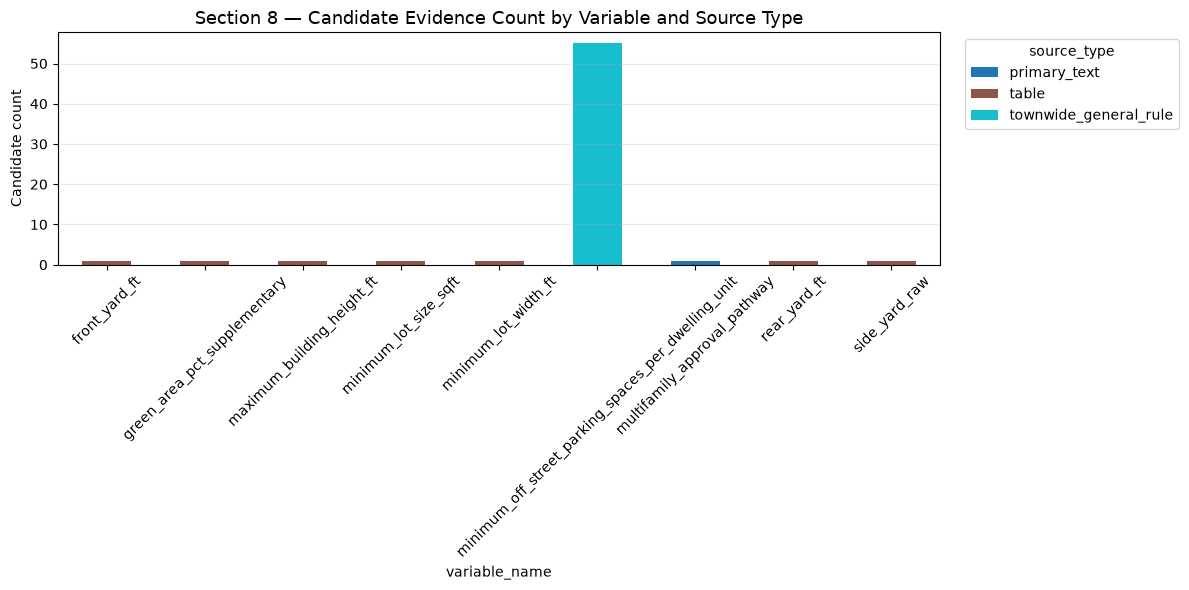

Saved: outputs/figures/phase2_section08_candidate_evidence_counts.png


In [36]:
fig, ax = plt.subplots(figsize=(12, 6))

evidence_counts = (
    candidate_evidence_df.groupby(["variable_name", "source_type"])
    .size()
    .unstack(fill_value=0)
)

evidence_counts.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")

ax.set_title("Section 8 — Candidate Evidence Count by Variable and Source Type", fontsize=13)
ax.set_ylabel("Candidate count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="source_type", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

evidence_count_figure_path = FIGURES_DIR / "phase2_section08_candidate_evidence_counts.png"
fig.savefig(evidence_count_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {evidence_count_figure_path.relative_to(STAGE_A_ROOT)}")

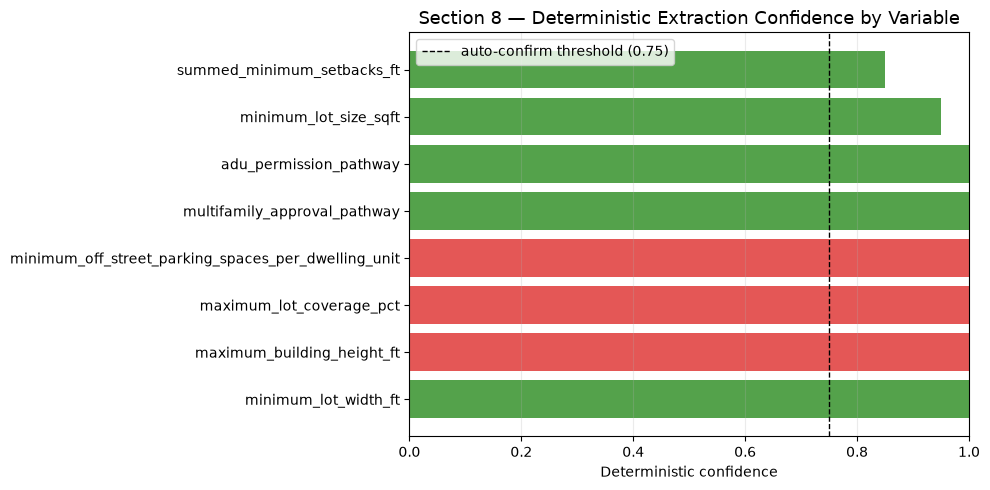

Saved: outputs/figures/phase2_section08_extraction_confidence.png


In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_df = town_rule_extractions_df.sort_values("deterministic_confidence", ascending=False)

bar_colors = np.where(
    plot_df["review_status"] == "confirmed", "#54A24B",
    np.where(plot_df["review_status"] == "review_required", "#F2CF5B", "#E45756"),
)

ax.barh(plot_df["variable_name"], plot_df["deterministic_confidence"], color=bar_colors)

ax.axvline(
    PHASE_2_CONFIG["minimum_confidence_for_auto_confirm"],
    color="black", linestyle="--", linewidth=1,
    label=f"auto-confirm threshold ({PHASE_2_CONFIG['minimum_confidence_for_auto_confirm']})",
)

ax.set_title("Section 8 — Deterministic Extraction Confidence by Variable", fontsize=13)
ax.set_xlabel("Deterministic confidence")
ax.set_xlim(0, 1)
ax.legend()
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

confidence_figure_path = FIGURES_DIR / "phase2_section08_extraction_confidence.png"
fig.savefig(confidence_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {confidence_figure_path.relative_to(STAGE_A_ROOT)}")

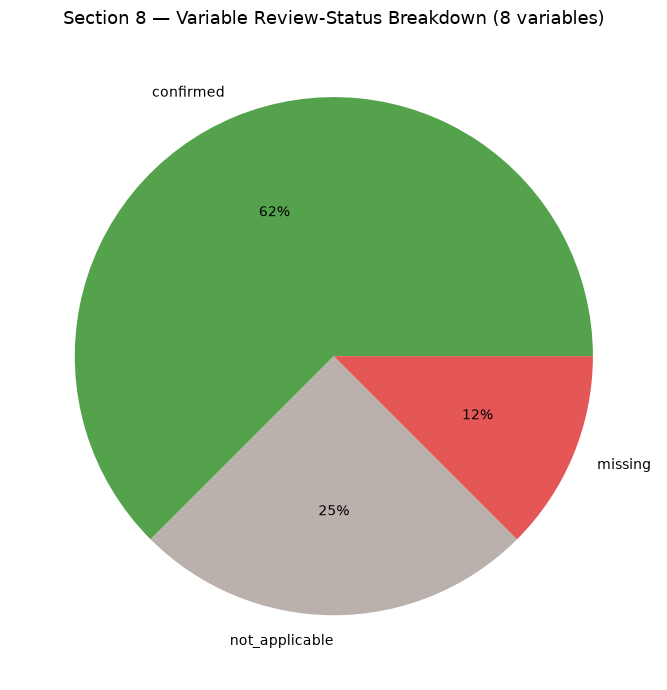

Saved: outputs/figures/phase2_section08_review_status_breakdown.png


In [38]:
fig, ax = plt.subplots(figsize=(7, 7))

status_counts = town_rule_extractions_df["review_status"].value_counts()

status_colors = {
    "confirmed": "#54A24B", "review_required": "#F2CF5B",
    "missing": "#E45756", "not_applicable": "#BAB0AC",
}

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.0f%%",
    colors=[status_colors.get(status, "#BAB0AC") for status in status_counts.index],
)

ax.set_title("Section 8 — Variable Review-Status Breakdown (8 variables)", fontsize=13)

plt.tight_layout()

review_status_figure_path = FIGURES_DIR / "phase2_section08_review_status_breakdown.png"
fig.savefig(review_status_figure_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {review_status_figure_path.relative_to(STAGE_A_ROOT)}")

In [39]:
confirmed_count = int((town_rule_extractions_df["review_status"] == "confirmed").sum())
not_applicable_count = int((town_rule_extractions_df["review_status"] == "not_applicable").sum())

# not_applicable is a distinct, real outcome -- the variable, as defined in
# the Version 1 schema, is not governed in that form for this district. It is
# never silently counted as confirmed, and it still blocks the strict
# all-eight-confirmed gate below: a not_applicable variable can only become
# scoreable by redesigning the statewide schema (e.g. a cross-town-comparable
# replacement concept) or by a clearly-labeled partial-score policy decision,
# neither of which this notebook does automatically.
phase_2_ready = (
    dominant_district_status == "verified"
    and confirmed_count == 8
    and input_summary["unresolved_conflict_count"] == 0
)

phase_2_status = "PHASE 2 READY FOR SCORING" if phase_2_ready else "PHASE 2 DIAGNOSTIC ONLY — SCORING BLOCKED"

print(phase_2_status)
print(f"Confirmed variables: {confirmed_count} / 8")
print(f"Not-applicable variables (distinct from missing/review_required): {not_applicable_count} / 8")
if not_applicable_count:
    print(
        "  -> Permanently blocked under the current schema until it is "
        "redesigned for cross-town comparability, or a clearly-labeled "
        "partial-score policy is adopted."
    )
print(f"Dominant district status: {dominant_district_status}")
print(f"Unresolved conflicts: {input_summary['unresolved_conflict_count']}")

town_rule_extractions_csv_path = TABLES_DIR / "greenwich_town_rule_extractions.csv"
town_rule_extractions_parquet_path = TABLES_DIR / "greenwich_town_rule_extractions.parquet"

town_rule_extractions_df.to_csv(town_rule_extractions_csv_path, index=False)

# source_id mixes table IDs (str) and page numbers (int) across rows; Parquet
# requires a single type per column, so stringify it for that export only.
town_rule_extractions_parquet_df = town_rule_extractions_df.copy()
town_rule_extractions_parquet_df["source_id"] = town_rule_extractions_parquet_df["source_id"].astype(str)
town_rule_extractions_parquet_df.to_parquet(town_rule_extractions_parquet_path, index=False)

validation_summary_df = pd.DataFrame(
    [
        {
            "phase_2_status": phase_2_status,
            "confirmed_variable_count": confirmed_count,
            "dominant_district_status": dominant_district_status,
            "target_district_code": TARGET_DISTRICT_CODE,
            "unresolved_conflict_count": input_summary["unresolved_conflict_count"],
        }
    ]
)
validation_summary_path = TABLES_DIR / "greenwich_phase_2_validation_summary.csv"
validation_summary_df.to_csv(validation_summary_path, index=False)

print(f"\nSaved: {town_rule_extractions_csv_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {town_rule_extractions_parquet_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {validation_summary_path.relative_to(STAGE_A_ROOT)}")

PHASE 2 DIAGNOSTIC ONLY — SCORING BLOCKED
Confirmed variables: 5 / 8
Not-applicable variables (distinct from missing/review_required): 2 / 8
  -> Permanently blocked under the current schema until it is redesigned for cross-town comparability, or a clearly-labeled partial-score policy is adopted.
Dominant district status: verified
Unresolved conflicts: 0

Saved: outputs/tables/greenwich_town_rule_extractions.csv
Saved: outputs/tables/greenwich_town_rule_extractions.parquet
Saved: outputs/tables/greenwich_phase_2_validation_summary.csv


## 9. Phase 3 reference-data loading and harmonization

The Connecticut Zoning Atlas (or an equivalent harmonized statewide dataset) is **never**
downloaded or invented automatically. If it is not present, this notebook creates a documented
template and runs Phase 3 in blocked diagnostic mode.

**To unblock Phase 3 scoring, manually supply a file at:**

```text
Stage_A_Zoning_Code_Reader/data/raw/reference/connecticut_zoning_atlas_harmonized.csv
```

with one row per Connecticut town and the columns listed in the template below. Every value in
that file must already be legally and conceptually comparable to this project's Phase 2
variables — unit conversions, categorical recodes, and known definitional differences from the
source dataset should be documented in `harmonization_note`.

In [40]:
REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_REQUIRED_COLUMNS = [
    "town", "minimum_lot_size_sqft", "minimum_lot_width_ft", "maximum_building_height_ft",
    "maximum_lot_coverage_pct", "summed_minimum_setbacks_ft",
    "minimum_off_street_parking_spaces_per_dwelling_unit",
    "multifamily_restrictiveness_ordinal", "adu_restrictiveness_ordinal",
    "source_dataset", "source_version", "source_date", "harmonization_note",
]

reference_data_status = "not_supplied"
reference_df = pd.DataFrame(columns=REFERENCE_REQUIRED_COLUMNS)

if not PHASE_3_CONFIG["reference_dataset_path"]:
    reference_data_status = "not_configured"
else:
    reference_path = Path(PHASE_3_CONFIG["reference_dataset_path"])

    if not reference_path.exists():
        pd.DataFrame(columns=REFERENCE_REQUIRED_COLUMNS).to_csv(reference_path, index=False)

        print(
            f"No reference dataset found. Created an empty template at:\n"
            f"  {reference_path.relative_to(STAGE_A_ROOT)}\n\n"
            "This file must be filled in manually with a legally and conceptually "
            "harmonized statewide reference dataset (e.g. derived from the "
            "Connecticut Zoning Atlas) before Phase 3 scoring can run. "
            f"Required columns: {REFERENCE_REQUIRED_COLUMNS}"
        )

        reference_data_status = "template_created_awaiting_manual_data"
    else:
        reference_df = pd.read_csv(reference_path)

        if reference_df.empty:
            reference_data_status = "template_present_but_empty"
        else:
            reference_data_status = "loaded"

print(f"\nreference_data_status = {reference_data_status}")


reference_data_status = template_present_but_empty


In [41]:
harmonization_issues = []

if reference_data_status == "loaded":
    missing_cols = [c for c in REFERENCE_REQUIRED_COLUMNS if c not in reference_df.columns]

    if missing_cols:
        harmonization_issues.append(f"Missing required columns: {missing_cols}")

    if "town" in reference_df.columns and reference_df["town"].duplicated().any():
        duplicated_towns = reference_df.loc[reference_df["town"].duplicated(), "town"].tolist()
        harmonization_issues.append(f"Duplicate town names: {duplicated_towns}")

    if "town" in reference_df.columns:
        greenwich_in_reference = PHASE_2_CONFIG["town"] in reference_df["town"].values
        harmonization_issues.append(
            f"Greenwich in-sample: {greenwich_in_reference} "
            "(affects whether an out-of-sample percentile procedure is needed)."
        )

    reference_population_size = len(reference_df)
else:
    reference_population_size = 0

harmonization_report_df = pd.DataFrame({"issue": harmonization_issues})

print(f"Reference population size: {reference_population_size}")
print()
harmonization_report_df

Reference population size: 0



,issue


## 10. Phase 3 orientation, percentiles, and composite score

Scoring only proceeds if **both** Phase 2 is ready (`phase_2_ready == True`) **and** a valid,
non-empty reference dataset is loaded. Otherwise the notebook writes a scoring-blocked report
naming exactly what is missing — it never calculates a partial or provisional public score in
Version 1.

In [42]:
def orient_value(variable_name: str, value: float) -> float | None:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None

    direction = PHASE_3_CONFIG["variable_directions"][variable_name]

    if direction == "smaller_is_more_restrictive":
        return -value

    return value


def recode_ordinal_to_restrictiveness(variable_name: str, permission_ordinal: int | None):
    if permission_ordinal is None:
        return None

    return 4 - permission_ordinal


reference_data_valid = reference_data_status == "loaded" and not harmonization_issues
scoring_can_run = phase_2_ready and reference_data_valid

print(f"phase_2_ready: {phase_2_ready}")
print(f"reference_data_valid: {reference_data_valid}")
print(f"scoring_can_run: {scoring_can_run}")

phase_2_ready: False
reference_data_valid: False
scoring_can_run: False


In [43]:
if not scoring_can_run:
    scoring_blockers = []

    if not phase_2_ready:
        scoring_blockers.append(
            f"Phase 2 is not ready: {confirmed_count}/8 variables confirmed, "
            f"dominant_district_status={dominant_district_status}, "
            f"unresolved_conflicts={input_summary['unresolved_conflict_count']}."
        )

    if not reference_data_valid:
        scoring_blockers.append(
            f"Reference data is not valid: status={reference_data_status}, "
            f"issues={harmonization_issues}."
        )

    scoring_blockers_df = pd.DataFrame({"blocker": scoring_blockers})
    scoring_blockers_path = TABLES_DIR / "greenwich_scoring_blockers.csv"
    scoring_blockers_df.to_csv(scoring_blockers_path, index=False)

    print("SCORING BLOCKED. Reasons:")
    for blocker in scoring_blockers:
        print(f"  - {blocker}")
    print(f"\nSaved: {scoring_blockers_path.relative_to(STAGE_A_ROOT)}")

    variable_percentiles_df = pd.DataFrame()
    town_score_df = pd.DataFrame()
else:
    print("Scoring prerequisites met — proceeding with Phase 3 calculation.")

SCORING BLOCKED. Reasons:
  - Phase 2 is not ready: 5/8 variables confirmed, dominant_district_status=verified, unresolved_conflicts=0.
  - Reference data is not valid: status=template_present_but_empty, issues=[].

Saved: outputs/tables/greenwich_scoring_blockers.csv


In [44]:
percentile_records = []

if scoring_can_run:
    reference_field_map = {
        "minimum_lot_size_sqft": "minimum_lot_size_sqft",
        "minimum_lot_width_ft": "minimum_lot_width_ft",
        "maximum_building_height_ft": "maximum_building_height_ft",
        "maximum_lot_coverage_pct": "maximum_lot_coverage_pct",
        "summed_minimum_setbacks_ft": "summed_minimum_setbacks_ft",
        "minimum_off_street_parking_spaces_per_dwelling_unit": (
            "minimum_off_street_parking_spaces_per_dwelling_unit"
        ),
        "multifamily_approval_pathway": "multifamily_restrictiveness_ordinal",
        "adu_permission_pathway": "adu_restrictiveness_ordinal",
    }

    for _, record in town_rule_extractions_df.iterrows():
        variable_name = record["variable_name"]

        if variable_name in {"multifamily_approval_pathway", "adu_permission_pathway"}:
            oriented_value = recode_ordinal_to_restrictiveness(
                variable_name, record["ordinal_permission_value"]
            )
        else:
            oriented_value = orient_value(variable_name, record["normalized_value"])

        reference_field = reference_field_map[variable_name]
        reference_values = reference_df[reference_field].dropna().astype(float)

        n = len(reference_values)
        less_count = int((reference_values < oriented_value).sum()) if n and oriented_value is not None else 0
        equal_count = int((reference_values == oriented_value).sum()) if n and oriented_value is not None else 0

        percentile = (
            100 * (less_count + 0.5 * equal_count) / n
            if n and oriented_value is not None
            else None
        )

        percentile_records.append(
            {
                "variable_name": variable_name,
                "raw_value": record["normalized_value"],
                "oriented_value": oriented_value,
                "reference_field": reference_field,
                "reference_population_size": n,
                "statewide_percentile": percentile,
                "weight": PHASE_3_CONFIG["equal_weight_per_variable"],
            }
        )

    variable_percentiles_df = pd.DataFrame(percentile_records)
    variable_percentiles_df["weighted_contribution"] = (
        variable_percentiles_df["statewide_percentile"] * variable_percentiles_df["weight"]
    )

    variable_percentiles_path = TABLES_DIR / "greenwich_variable_percentiles.csv"
    variable_percentiles_df.to_csv(variable_percentiles_path, index=False)

    print(f"Saved: {variable_percentiles_path.relative_to(STAGE_A_ROOT)}")
    display(variable_percentiles_df)
else:
    variable_percentiles_df = pd.DataFrame()

In [45]:
if scoring_can_run:
    composite_score = variable_percentiles_df["weighted_contribution"].sum()

    town_score_df = pd.DataFrame(
        [
            {
                "town": PHASE_2_CONFIG["town"],
                "state": PHASE_2_CONFIG["state"],
                "dominant_district_code": TARGET_DISTRICT_CODE,
                "town_score": composite_score,
                "score_eligibility_status": "published",
                "reference_population_size": reference_population_size,
                "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
                "document_hash_sha256": input_summary["document_hash_sha256"],
            }
        ]
    )

    town_score_path = TABLES_DIR / "greenwich_town_score.csv"
    town_score_df.to_csv(town_score_path, index=False)

    print(f"Greenwich town score: {composite_score:.1f} / 100")
    print(f"Saved: {town_score_path.relative_to(STAGE_A_ROOT)}")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        variable_percentiles_df["variable_name"],
        variable_percentiles_df["statewide_percentile"],
        color="#4C78A8",
    )
    ax.axvline(composite_score, color="#E45756", linestyle="--", label=f"composite = {composite_score:.1f}")
    ax.set_xlim(0, 100)
    ax.set_title(f"Section 10 — {PHASE_2_CONFIG['town']} Statewide Percentile by Variable", fontsize=13)
    ax.set_xlabel("Statewide percentile (higher = more restrictive)")
    ax.legend()
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()

    scoring_contribution_figure_path = FIGURES_DIR / "phase3_section10_scoring_contribution.png"
    fig.savefig(scoring_contribution_figure_path, dpi=220, bbox_inches="tight")
    plt.show()
else:
    composite_score = None
    print("No town score calculated (scoring blocked). See greenwich_scoring_blockers.csv.")

No town score calculated (scoring blocked). See greenwich_scoring_blockers.csv.


## 11. Sensitivity analysis

Alternative weighting scenarios and the most-restrictive-district alternate are only calculated
when a baseline score actually exists. A single-town Greenwich run **cannot** establish rank
stability (that requires a multi-town reference population) — this notebook reports Greenwich's
own scenario scores only, and explicitly defers rank-correlation analysis to a multi-town run.

In [46]:
SENSITIVITY_WEIGHT_SCENARIOS = {
    "baseline_equal_weight": {variable: 1 / 8 for variable in PHASE_2_CONFIG["variables"]},
    "dimensional_emphasis": {
        "minimum_lot_size_sqft": 0.2, "minimum_lot_width_ft": 0.15,
        "maximum_building_height_ft": 0.15, "maximum_lot_coverage_pct": 0.15,
        "summed_minimum_setbacks_ft": 0.15,
        "minimum_off_street_parking_spaces_per_dwelling_unit": 0.1,
        "multifamily_approval_pathway": 0.05, "adu_permission_pathway": 0.05,
    },
    "housing_type_emphasis": {
        "minimum_lot_size_sqft": 0.1, "minimum_lot_width_ft": 0.1,
        "maximum_building_height_ft": 0.1, "maximum_lot_coverage_pct": 0.1,
        "summed_minimum_setbacks_ft": 0.1,
        "minimum_off_street_parking_spaces_per_dwelling_unit": 0.1,
        "multifamily_approval_pathway": 0.2, "adu_permission_pathway": 0.2,
    },
    "parking_emphasis": {
        "minimum_lot_size_sqft": 0.125, "minimum_lot_width_ft": 0.125,
        "maximum_building_height_ft": 0.125, "maximum_lot_coverage_pct": 0.125,
        "summed_minimum_setbacks_ft": 0.125,
        "minimum_off_street_parking_spaces_per_dwelling_unit": 0.25,
        "multifamily_approval_pathway": 0.0625, "adu_permission_pathway": 0.0625,
    },
}

sensitivity_records = []

if scoring_can_run:
    for scenario_name, weights in SENSITIVITY_WEIGHT_SCENARIOS.items():
        scenario_score = sum(
            weights[row["variable_name"]] * row["statewide_percentile"]
            for _, row in variable_percentiles_df.iterrows()
        )

        sensitivity_records.append(
            {
                "scenario": scenario_name,
                "score": scenario_score,
                "difference_from_baseline": scenario_score - composite_score,
            }
        )

    for held_out_variable in PHASE_2_CONFIG["variables"]:
        remaining = variable_percentiles_df.loc[
            variable_percentiles_df["variable_name"] != held_out_variable
        ]
        leave_one_out_score = remaining["statewide_percentile"].mean()

        sensitivity_records.append(
            {
                "scenario": f"leave_one_out__{held_out_variable}",
                "score": leave_one_out_score,
                "difference_from_baseline": leave_one_out_score - composite_score,
            }
        )

    sensitivity_records.append(
        {
            "scenario": "most_restrictive_district_alternate",
            "score": None,
            "difference_from_baseline": None,
            "status": "unavailable: requires confirmed rule values for every base "
            "residential district, not only the dominant district",
        }
    )

    greenwich_sensitivity_df = pd.DataFrame(sensitivity_records)

    print(
        "Note: these are Greenwich's own scenario scores only. Rank-correlation / "
        "rank-stability analysis is reserved for a multi-town run, per the framework."
    )
else:
    greenwich_sensitivity_df = pd.DataFrame(
        columns=["scenario", "score", "difference_from_baseline", "status"]
    )
    print("Sensitivity analysis skipped (scoring blocked). Saving an empty, documented framework only.")

sensitivity_path = TABLES_DIR / "greenwich_sensitivity_analysis.csv"
greenwich_sensitivity_df.to_csv(sensitivity_path, index=False)
print(f"Saved: {sensitivity_path.relative_to(STAGE_A_ROOT)}")

greenwich_sensitivity_df

Sensitivity analysis skipped (scoring blocked). Saving an empty, documented framework only.
Saved: outputs/tables/greenwich_sensitivity_analysis.csv


,scenario,score,difference_from_baseline,status


In [47]:
if scoring_can_run and not greenwich_sensitivity_df.empty:
    plot_df = greenwich_sensitivity_df.loc[
        ~greenwich_sensitivity_df["scenario"].str.startswith("leave_one_out")
        & (greenwich_sensitivity_df["score"].notna())
    ]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(plot_df["scenario"], plot_df["score"], color="#F58518")
    ax.axhline(composite_score, color="#4C78A8", linestyle="--", label="baseline")
    ax.set_title("Section 11 — Sensitivity Scenario Scores (Greenwich only)", fontsize=13)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", rotation=20)
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    sensitivity_figure_path = FIGURES_DIR / "phase3_section11_sensitivity.png"
    fig.savefig(sensitivity_figure_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {sensitivity_figure_path.relative_to(STAGE_A_ROOT)}")
else:
    print("No sensitivity chart generated (scoring blocked).")

No sensitivity chart generated (scoring blocked).


## 12. Final exports and reproducibility manifest

Every required export is consolidated here into a single combined manifest for Phase 2 and
Phase 3, alongside the individual run logs already written in each section above.

In [48]:
phase_2_run_log = {
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "town": PHASE_2_CONFIG["town"],
    "target_district_code": TARGET_DISTRICT_CODE,
    "dominant_district_status": dominant_district_status,
    "confirmed_variable_count": confirmed_count,
    "phase_2_status": phase_2_status,
    "legal_bert_used": LEGAL_BERT_MODEL is not None,
}

phase_2_run_log_path = LOGS_DIR / "phase_2_run_log.json"
with phase_2_run_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(phase_2_run_log, file_handle, indent=2, default=str)

phase_3_run_log = {
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "reference_data_status": reference_data_status,
    "reference_population_size": reference_population_size,
    "scoring_can_run": scoring_can_run,
    "town_score": float(composite_score) if composite_score is not None else None,
}

phase_3_run_log_path = LOGS_DIR / "phase_3_run_log.json"
with phase_3_run_log_path.open("w", encoding="utf-8") as file_handle:
    json.dump(phase_3_run_log, file_handle, indent=2, default=str)

print(f"Saved: {phase_2_run_log_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {phase_3_run_log_path.relative_to(STAGE_A_ROOT)}")

Saved: outputs/logs/phase_2_run_log.json
Saved: outputs/logs/phase_3_run_log.json


In [49]:
export_paths = {
    "town_rule_extractions_csv": town_rule_extractions_csv_path,
    "town_rule_extractions_parquet": town_rule_extractions_parquet_path,
    "rule_candidate_evidence": candidate_evidence_path,
    "phase_2_conflict_audit": candidate_conflict_audit_path,
    "phase_2_review_queue": review_queue_path,
    "phase_2_validation_summary": validation_summary_path,
    "dominant_district_decision": dominant_district_decision_path,
    "manual_override_audit": manual_override_audit_path,
    "auxiliary_evidence": auxiliary_evidence_path,
    "sensitivity_analysis": sensitivity_path,
}

if scoring_can_run:
    export_paths["variable_percentiles"] = variable_percentiles_path
    export_paths["town_score"] = town_score_path
else:
    export_paths["scoring_blockers"] = TABLES_DIR / "greenwich_scoring_blockers.csv"

combined_manifest = {
    "document_id": input_summary["document_id"],
    "document_hash_sha256": input_summary["document_hash_sha256"],
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "dominant_district_status": dominant_district_status,
    "phase_2_status": phase_2_status,
    "phase_3_scoring_status": "published" if scoring_can_run else "blocked",
    "confirmed_variable_count": confirmed_count,
    "review_required_variable_count": int(
        (town_rule_extractions_df["review_status"] == "review_required").sum()
    ),
    "missing_variable_count": int(
        (town_rule_extractions_df["review_status"] == "missing").sum()
    ),
    "not_applicable_variable_count": not_applicable_count,
    "unresolved_conflict_count": input_summary["unresolved_conflict_count"],
    "legal_bert_available": TRANSFORMERS_AVAILABLE,
    "legal_bert_used": LEGAL_BERT_MODEL is not None,
    "known_blockers": (
        [] if phase_2_ready and scoring_can_run else
        [b for b in [
            None if dominant_district_status == "verified" else "dominant_district_unverified",
            None if confirmed_count == 8 else f"only_{confirmed_count}_of_8_variables_confirmed",
            None if reference_data_valid else "reference_dataset_missing_or_invalid",
        ] if b]
    ),
    "export_paths": {name: str(path.relative_to(STAGE_A_ROOT)) for name, path in export_paths.items()},
}

manifest_path = LOGS_DIR / "combined_phase_2_phase_3_manifest.json"
with manifest_path.open("w", encoding="utf-8") as file_handle:
    json.dump(combined_manifest, file_handle, indent=2, default=str)

print(f"Saved: {manifest_path.relative_to(STAGE_A_ROOT)}")
pd.DataFrame(
    [{"export": name, "path": str(path.relative_to(STAGE_A_ROOT))} for name, path in export_paths.items()]
)

Saved: outputs/logs/combined_phase_2_phase_3_manifest.json


,export,path
0,town_rule_extractions_csv,outputs/tables/greenwich_town_rule_extractions.csv
1,town_rule_extractions_parquet,outputs/tables/greenwich_town_rule_extractions.parquet
2,rule_candidate_evidence,outputs/tables/greenwich_rule_candidate_evidence.csv
3,phase_2_conflict_audit,outputs/tables/greenwich_phase_2_conflict_audit.csv
4,phase_2_review_queue,outputs/review/greenwich_phase_2_review_queue.csv
5,phase_2_validation_summary,outputs/tables/greenwich_phase_2_validation_summary.csv
6,dominant_district_decision,outputs/tables/greenwich_dominant_district_decision.csv
7,manual_override_audit,outputs/tables/greenwich_phase_2_manual_override_audit.csv
8,auxiliary_evidence,outputs/tables/greenwich_phase_2_auxiliary_evidence.csv
9,sensitivity_analysis,outputs/tables/greenwich_sensitivity_analysis.csv


## 13. Final notebook status

In [50]:
if phase_2_ready and scoring_can_run:
    print(
        "GREENWICH PHASE 2 AND PHASE 3 COMPLETE: all eight variables confirmed, "
        "dominant district verified, reference data validated, and town score generated."
    )
else:
    print(
        "GREENWICH PHASE 2/PHASE 3 DIAGNOSTIC RUN COMPLETE: no publishable town "
        "score was generated because one or more gating requirements remain unmet."
    )

print()
print(f"- Dominant district status: {dominant_district_status} (target used for diagnostics: {TARGET_DISTRICT_CODE})")
print(f"- Confirmed rules: {confirmed_count} / 8")
print(f"- Not applicable (distinct from missing/review_required): {not_applicable_count} / 8")
print(
    f"- Review required: {int((town_rule_extractions_df['review_status'] == 'review_required').sum())} / 8"
)
print(f"- Missing: {int((town_rule_extractions_df['review_status'] == 'missing').sum())} / 8")
print(f"- Unresolved conflicts: {input_summary['unresolved_conflict_count']}")
print(f"- Reference-data status: {reference_data_status}")
print(f"- Phase 3 scoring status: {'published' if scoring_can_run else 'blocked'}")
print()
print("Final output locations:")
for name, path in export_paths.items():
    print(f"  {name}: {path.relative_to(STAGE_A_ROOT)}")
print(f"  combined manifest: {manifest_path.relative_to(STAGE_A_ROOT)}")

GREENWICH PHASE 2/PHASE 3 DIAGNOSTIC RUN COMPLETE: no publishable town score was generated because one or more gating requirements remain unmet.

- Dominant district status: verified (target used for diagnostics: RA-4)
- Confirmed rules: 5 / 8
- Not applicable (distinct from missing/review_required): 2 / 8
- Review required: 0 / 8
- Missing: 1 / 8
- Unresolved conflicts: 0
- Reference-data status: template_present_but_empty
- Phase 3 scoring status: blocked

Final output locations:
  town_rule_extractions_csv: outputs/tables/greenwich_town_rule_extractions.csv
  town_rule_extractions_parquet: outputs/tables/greenwich_town_rule_extractions.parquet
  rule_candidate_evidence: outputs/tables/greenwich_rule_candidate_evidence.csv
  phase_2_conflict_audit: outputs/tables/greenwich_phase_2_conflict_audit.csv
  phase_2_review_queue: outputs/review/greenwich_phase_2_review_queue.csv
  phase_2_validation_summary: outputs/tables/greenwich_phase_2_validation_summary.csv
  dominant_district_decisio

## 14. Greenwich Prototype Scoring Mode

This section sits **beside** the statewide Phase 3 scoring above — it does not replace it. It
exists because, with \(N=1\) town, a statewide percentile score is mathematically meaningless
(there is no reference distribution to rank against). What *is* possible with one town is an
end-to-end proof that the pipeline can turn source evidence into a reproducible composite, using
an explicit, documented, prototype-only scoring rubric.

```text
GREENWICH PROTOTYPE SCORE —
NOT A CONNECTICUT STATEWIDE PERCENTILE OR RANKING.
```

### Why `not_applicable` is never auto-scored as 0 or 100

A variable that is `not_applicable` under the Version 1 eight-variable schema (lot coverage,
numeric parking) is not evidence of permissiveness or restrictiveness — it means the schema asked
the wrong question for this district. Those two fields stay **informational only** below. Where a
real, numeric physical-constraint substitute exists in the evidence already collected (minimum
green area, in place of lot coverage), that substitute is scored instead — never the schema
field it cannot answer, and never a fabricated conversion.

### The ten components

| # | Component | Scored? | Greenwich value |
|---|---|---|---|
| 1 | Minimum lot area | Yes | 174,240 sq ft |
| 2 | Minimum lot width | Yes | 200 ft |
| 3 | Aggregate setbacks | Yes | 250 ft |
| 4 | Height constraint (stories) | Yes | 3.5 stories |
| 5 | Green-area requirement | Yes | 84% |
| 6 | Lot-coverage applicability | **No — informational only** | not_applicable |
| 7 | Parking regime | Yes | qualitative sufficiency standard |
| 8 | Multifamily pathway | Yes | prohibited |
| 9 | ADU pathway | Yes | allowed_subject_to_objective_conditions |
| 10 | Residential approval process | Yes | by right (derived from §6-93(a)(1)) |

Nine components are scored with equal weight \(w_k = 1/9\); the lot-coverage-applicability field
is reported alongside but excluded from the weighted sum, per the explicit correction above.

In [51]:
GREENWICH_PROTOTYPE_RUBRIC = {
    "minimum_lot_area_sqft": {
        "bands": [
            (0, 0), (10_000, 25), (21_780, 50), (43_560, 75), (87_120, 100),
        ],
        "description": "Larger required lot area is scored as more restrictive.",
    },
    "minimum_lot_width_ft": {
        "bands": [
            (0, 0), (75, 25), (125, 50), (175, 75), (250, 100),
        ],
        "description": "Wider required lot is scored as more restrictive.",
    },
    "summed_setbacks_ft": {
        "bands": [
            (0, 0), (80, 25), (140, 50), (200, 75), (300, 100),
        ],
        "description": "Larger combined building-envelope setback is scored as more restrictive.",
    },
    "height_constraint_stories": {
        # Descending: a LOWER story limit is more restrictive. The source
        # material only supplied three example points (<=2.5, 3, >=4);
        # Greenwich's real RA-4 value (3.5 stories) falls in the gap between
        # "3 stories" and ">=4 stories" that the example rubric left
        # undefined. A midpoint band is added here to fill that gap
        # explicitly, documented as a prototype-engineering choice rather
        # than silently interpolated.
        "bands_descending": [
            (4.0, 0), (3.5, 25), (3.0, 50), (2.5, 100),
        ],
        "description": (
            "Lower permitted story count is scored as more restrictive. "
            "The 3.0-3.5 story band was added to fill a gap in the source "
            "example rubric, which only specified <=2.5, 3, and >=4 stories."
        ),
    },
    "green_area_pct": {
        "bands": [
            (0, 0), (25, 25), (50, 50), (70, 75), (85, 100),
        ],
        "description": "A higher required green/open-area percentage is scored as more restrictive.",
    },
    "parking_regime": {
        "categories": {
            "no_stated_minimum": 0,
            "qualitative_sufficiency": 25,
            "numeric_low": 50,
            "numeric_moderate": 75,
            "numeric_high_or_formulaic": 100,
        },
        "description": "A more burdensome parking regulation form is scored as more restrictive.",
    },
    "multifamily_pathway": {
        "categories": {
            "permitted_by_right": 0,
            "administrative_review": 25,
            "special_permit": 50,
            "rezoning_required": 75,
            "prohibited": 100,
        },
        "description": "A more restrictive housing-type permission pathway scores higher.",
    },
    "adu_pathway": {
        "categories": {
            "allowed_by_right": 0,
            "allowed_subject_to_objective_conditions": 25,
            "conditional_discretionary_approval": 50,
            "effectively_unavailable": 75,
            "prohibited": 100,
        },
        "description": "A more restrictive ADU pathway scores higher.",
    },
    "residential_approval_process": {
        "categories": {
            "by_right": 0,
            "administrative_permit": 25,
            "special_permit": 50,
            "variance_or_rezoning": 75,
            "prohibited": 100,
        },
        "description": "A more discretionary principal-use approval process scores higher.",
    },
}

GREENWICH_PROTOTYPE_WEIGHT_PER_COMPONENT = 1 / 9

rubric_rows = []
for component, spec in GREENWICH_PROTOTYPE_RUBRIC.items():
    band_source = spec.get("bands") or spec.get("bands_descending") or list(spec["categories"].items())
    rubric_rows.append(
        {
            "component": component,
            "description": spec["description"],
            "bands_or_categories": str(band_source),
        }
    )

greenwich_prototype_rubric_df = pd.DataFrame(rubric_rows)

GREENWICH_PROTOTYPE_TABLES_DIR = TABLES_DIR / "greenwich_prototype_final"
GREENWICH_PROTOTYPE_FIGURES_DIR = FIGURES_DIR / "greenwich_prototype_final"
GREENWICH_PROTOTYPE_REVIEW_DIR = REVIEW_DIR / "greenwich_prototype_final"

for directory in [
    GREENWICH_PROTOTYPE_TABLES_DIR,
    GREENWICH_PROTOTYPE_FIGURES_DIR,
    GREENWICH_PROTOTYPE_REVIEW_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

rubric_path = GREENWICH_PROTOTYPE_TABLES_DIR / "greenwich_prototype_scoring_rubric.csv"
greenwich_prototype_rubric_df.to_csv(rubric_path, index=False)

print(f"Saved: {rubric_path.relative_to(STAGE_A_ROOT)}")
greenwich_prototype_rubric_df

Saved: outputs/tables/greenwich_prototype_final/greenwich_prototype_scoring_rubric.csv


,component,description,bands_or_categories
0,minimum_lot_area_sqft,Larger required lot area is scored as more restrictive.,"[(0, 0), (10000, 25), (21780, 50), (43560, 75), (87120, ..."
1,minimum_lot_width_ft,Wider required lot is scored as more restrictive.,"[(0, 0), (75, 25), (125, 50), (175, 75), (250, 100)]"
2,summed_setbacks_ft,Larger combined building-envelope setback is scored as m...,"[(0, 0), (80, 25), (140, 50), (200, 75), (300, 100)]"
3,height_constraint_stories,Lower permitted story count is scored as more restrictiv...,"[(4.0, 0), (3.5, 25), (3.0, 50), (2.5, 100)]"
4,green_area_pct,A higher required green/open-area percentage is scored a...,"[(0, 0), (25, 25), (50, 50), (70, 75), (85, 100)]"
5,parking_regime,A more burdensome parking regulation form is scored as m...,"[('no_stated_minimum', 0), ('qualitative_sufficiency', 2..."
6,multifamily_pathway,A more restrictive housing-type permission pathway score...,"[('permitted_by_right', 0), ('administrative_review', 25..."
7,adu_pathway,A more restrictive ADU pathway scores higher.,"[('allowed_by_right', 0), ('allowed_subject_to_objective..."
8,residential_approval_process,A more discretionary principal-use approval process scor...,"[('by_right', 0), ('administrative_permit', 25), ('speci..."


In [52]:
def score_ascending_bands(value: float, bands: list[tuple[float, int]]) -> int:
    score = bands[0][1]
    for threshold, band_score in bands:
        if value >= threshold:
            score = band_score
    return score


def score_descending_bands(value: float, bands_descending: list[tuple[float, int]]) -> int:
    for threshold, band_score in bands_descending:
        if value >= threshold:
            return band_score
    return bands_descending[-1][1]


def get_confirmed_value(variable_name: str):
    row = town_rule_extractions_df.loc[
        town_rule_extractions_df["variable_name"] == variable_name
    ]
    if row.empty:
        return None
    return row.iloc[0]


def get_auxiliary_value(field_name: str):
    row = auxiliary_evidence_df.loc[auxiliary_evidence_df["field_name"] == field_name]
    if row.empty:
        return None
    return row.iloc[0]["value"]


component_records = []

lot_area_row = get_confirmed_value("minimum_lot_size_sqft")
lot_area_value = lot_area_row["normalized_value"] if lot_area_row is not None else None
component_records.append(
    {
        "component": "minimum_lot_area_sqft",
        "raw_value": lot_area_value,
        "score": (
            score_ascending_bands(lot_area_value, GREENWICH_PROTOTYPE_RUBRIC["minimum_lot_area_sqft"]["bands"])
            if lot_area_value is not None else None
        ),
        "scored": True,
        "source": "minimum_lot_size_sqft (confirmed)",
    }
)

lot_width_row = get_confirmed_value("minimum_lot_width_ft")
lot_width_value = lot_width_row["normalized_value"] if lot_width_row is not None else None
component_records.append(
    {
        "component": "minimum_lot_width_ft",
        "raw_value": lot_width_value,
        "score": (
            score_ascending_bands(lot_width_value, GREENWICH_PROTOTYPE_RUBRIC["minimum_lot_width_ft"]["bands"])
            if lot_width_value is not None else None
        ),
        "scored": True,
        "source": "minimum_lot_width_ft (confirmed)",
    }
)

setbacks_row = get_confirmed_value("summed_minimum_setbacks_ft")
setbacks_value = setbacks_row["normalized_value"] if setbacks_row is not None else None
component_records.append(
    {
        "component": "summed_setbacks_ft",
        "raw_value": setbacks_value,
        "score": (
            score_ascending_bands(setbacks_value, GREENWICH_PROTOTYPE_RUBRIC["summed_setbacks_ft"]["bands"])
            if setbacks_value is not None else None
        ),
        "scored": True,
        "source": "summed_minimum_setbacks_ft (confirmed)",
    }
)

height_stories_value = get_auxiliary_value("maximum_building_height_stories")
component_records.append(
    {
        "component": "height_constraint_stories",
        "raw_value": height_stories_value,
        "score": (
            score_descending_bands(
                height_stories_value,
                GREENWICH_PROTOTYPE_RUBRIC["height_constraint_stories"]["bands_descending"],
            )
            if height_stories_value is not None else None
        ),
        "scored": True,
        "source": "maximum_building_height_stories (auxiliary evidence)",
    }
)

green_area_value = get_auxiliary_value("minimum_green_area_pct")
component_records.append(
    {
        "component": "green_area_pct",
        "raw_value": green_area_value,
        "score": (
            score_ascending_bands(green_area_value, GREENWICH_PROTOTYPE_RUBRIC["green_area_pct"]["bands"])
            if green_area_value is not None else None
        ),
        "scored": True,
        "source": "minimum_green_area_pct (auxiliary evidence)",
    }
)

coverage_row = get_confirmed_value("maximum_lot_coverage_pct")
component_records.append(
    {
        "component": "lot_coverage_applicability",
        "raw_value": coverage_row["review_status"] if coverage_row is not None else None,
        "score": None,
        "scored": False,
        "source": "maximum_lot_coverage_pct (informational only, not scored)",
    }
)

parking_row = get_confirmed_value("minimum_off_street_parking_spaces_per_dwelling_unit")
parking_note = str(parking_row["review_note"]) if parking_row is not None else ""
parking_category = (
    "qualitative_sufficiency" if "qualitative" in parking_note.lower() else "no_stated_minimum"
)
component_records.append(
    {
        "component": "parking_regime",
        "raw_value": parking_category,
        "score": GREENWICH_PROTOTYPE_RUBRIC["parking_regime"]["categories"][parking_category],
        "scored": True,
        "source": "minimum_off_street_parking_spaces_per_dwelling_unit review note (confirmed not_applicable; qualitative standard identified)",
    }
)

multifamily_row = get_confirmed_value("multifamily_approval_pathway")
multifamily_category = (
    multifamily_row["categorical_value"] if multifamily_row is not None else None
)
component_records.append(
    {
        "component": "multifamily_pathway",
        "raw_value": multifamily_category,
        "score": (
            GREENWICH_PROTOTYPE_RUBRIC["multifamily_pathway"]["categories"].get(multifamily_category)
            if multifamily_category else None
        ),
        "scored": True,
        "source": "multifamily_approval_pathway (confirmed)",
    }
)

adu_row = get_confirmed_value("adu_permission_pathway")
adu_category = adu_row["categorical_value"] if adu_row is not None else None
component_records.append(
    {
        "component": "adu_pathway",
        "raw_value": adu_category,
        "score": (
            GREENWICH_PROTOTYPE_RUBRIC["adu_pathway"]["categories"].get(adu_category)
            if adu_category else None
        ),
        "scored": True,
        "source": "adu_permission_pathway (confirmed)",
    }
)

# Residential approval process is derived from the same already-confirmed
# multifamily evidence: Sec. 6-93(a)(1) lists detached single-family
# dwellings as a PERMITTED (by-right) principal use -- not a Sec. 6-94
# special-permit use -- so no discretionary approval governs the principal
# single-family use itself in RA-4.
residential_approval_category = "by_right"
component_records.append(
    {
        "component": "residential_approval_process",
        "raw_value": residential_approval_category,
        "score": GREENWICH_PROTOTYPE_RUBRIC["residential_approval_process"]["categories"][residential_approval_category],
        "scored": True,
        "source": "Derived from §6-93(a)(1): detached single-family dwellings are a permitted (by-right) principal use, not listed under §6-94's special-permit uses.",
    }
)

greenwich_prototype_components_df = pd.DataFrame(component_records)

components_path = GREENWICH_PROTOTYPE_TABLES_DIR / "greenwich_prototype_score_components.csv"
greenwich_prototype_components_df.to_csv(components_path, index=False)

print(f"Saved: {components_path.relative_to(STAGE_A_ROOT)}")
greenwich_prototype_components_df

Saved: outputs/tables/greenwich_prototype_final/greenwich_prototype_score_components.csv


,component,raw_value,score,scored,source
0,minimum_lot_area_sqft,174240.0,100.0,True,minimum_lot_size_sqft (confirmed)
1,minimum_lot_width_ft,200.0,75.0,True,minimum_lot_width_ft (confirmed)
2,summed_setbacks_ft,250.0,75.0,True,summed_minimum_setbacks_ft (confirmed)
3,height_constraint_stories,3.5,25.0,True,maximum_building_height_stories (auxiliary evidence)
4,green_area_pct,84.0,75.0,True,minimum_green_area_pct (auxiliary evidence)
5,lot_coverage_applicability,not_applicable,NaN,False,"maximum_lot_coverage_pct (informational only, not scored)"
6,parking_regime,qualitative_sufficiency,25.0,True,minimum_off_street_parking_spaces_per_dwelling_unit revi...
7,multifamily_pathway,prohibited,100.0,True,multifamily_approval_pathway (confirmed)
8,adu_pathway,allowed_subject_to_objective_conditions,25.0,True,adu_permission_pathway (confirmed)
9,residential_approval_process,by_right,0.0,True,Derived from §6-93(a)(1): detached single-family dwellin...


In [53]:
scored_components_df = greenwich_prototype_components_df.loc[
    greenwich_prototype_components_df["scored"]
]

if scored_components_df["score"].isna().any():
    unscored = scored_components_df.loc[scored_components_df["score"].isna(), "component"].tolist()
    raise ValueError(
        f"One or more scored components has no score value: {unscored}. "
        "The Greenwich prototype score requires every scored component to "
        "have a real band/category match."
    )

greenwich_prototype_score = scored_components_df["score"].mean()

greenwich_prototype_score_summary_df = pd.DataFrame(
    [
        {
            "town": PHASE_2_CONFIG["town"],
            "score_label": "GREENWICH PROTOTYPE SCORE -- NOT A CONNECTICUT STATEWIDE PERCENTILE OR RANKING",
            "greenwich_prototype_score": greenwich_prototype_score,
            "scored_component_count": len(scored_components_df),
            "informational_component_count": int((~greenwich_prototype_components_df["scored"]).sum()),
            "weight_per_component": GREENWICH_PROTOTYPE_WEIGHT_PER_COMPONENT,
            "dominant_district": TARGET_DISTRICT_CODE,
            "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
        }
    ]
)

print(f"GREENWICH PROTOTYPE SCORE: {greenwich_prototype_score:.1f} / 100")
print("NOT A CONNECTICUT STATEWIDE PERCENTILE OR RANKING -- a single-town pipeline proof only.")

score_summary_path = GREENWICH_PROTOTYPE_TABLES_DIR / "greenwich_prototype_score_summary.csv"
greenwich_prototype_score_summary_df.to_csv(score_summary_path, index=False)

print(f"Saved: {score_summary_path.relative_to(STAGE_A_ROOT)}")
greenwich_prototype_score_summary_df

GREENWICH PROTOTYPE SCORE: 55.6 / 100
NOT A CONNECTICUT STATEWIDE PERCENTILE OR RANKING -- a single-town pipeline proof only.
Saved: outputs/tables/greenwich_prototype_final/greenwich_prototype_score_summary.csv


,town,score_label,greenwich_prototype_score,scored_component_count,informational_component_count,weight_per_component,dominant_district,pipeline_run_timestamp
0,Greenwich,GREENWICH PROTOTYPE SCORE -- NOT A CONNECTICUT STATEWIDE...,55.555556,9,1,0.111111,RA-4,2026-10-01T09:09:02.964715+00:00


### Evidence profile, audit history, and limitations

The full evidence profile, the automatic-vs-manual audit trail, and the manual-review history are
consolidated here into their final prototype-run exports, alongside an explicit, itemized
limitations file -- so nothing about this score's scope is left implicit.

In [54]:
evidence_profile_columns = [
    "variable_name", "review_status", "categorical_value", "normalized_value",
    "normalized_unit", "source_type", "source_page", "source_excerpt", "review_note",
]

greenwich_evidence_profile_df = town_rule_extractions_df[evidence_profile_columns].copy()

evidence_profile_path = GREENWICH_PROTOTYPE_TABLES_DIR / "greenwich_evidence_profile.csv"
greenwich_evidence_profile_df.to_csv(evidence_profile_path, index=False)

rule_extraction_audit_df = pd.concat(
    [
        candidate_conflict_audit_df.assign(audit_source="automatic_candidate_audit"),
        manual_override_audit_df.assign(audit_source="manual_override_audit"),
    ],
    ignore_index=True,
)

rule_extraction_audit_path = GREENWICH_PROTOTYPE_TABLES_DIR / "greenwich_rule_extraction_audit.csv"
rule_extraction_audit_df.to_csv(rule_extraction_audit_path, index=False)

manual_review_history_path = GREENWICH_PROTOTYPE_TABLES_DIR / "greenwich_manual_review_history.csv"
manual_review_df.to_csv(manual_review_history_path, index=False)

print(f"Saved: {evidence_profile_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {rule_extraction_audit_path.relative_to(STAGE_A_ROOT)}")
print(f"Saved: {manual_review_history_path.relative_to(STAGE_A_ROOT)}")

Saved: outputs/tables/greenwich_prototype_final/greenwich_evidence_profile.csv
Saved: outputs/tables/greenwich_prototype_final/greenwich_rule_extraction_audit.csv
Saved: outputs/tables/greenwich_prototype_final/greenwich_manual_review_history.csv


In [55]:
scoring_assumptions_and_limitations = [
    {
        "assumption_or_limitation": (
            "This is a single-town (N=1) prototype score, not a statewide "
            "percentile. It cannot be compared across towns or published as "
            "a Connecticut ranking."
        ),
    },
    {
        "assumption_or_limitation": (
            "The 10-component rubric and its band thresholds are prototype "
            "engineering choices documented in "
            "greenwich_prototype_scoring_rubric.csv -- not empirically "
            "derived or statewide-validated cut points."
        ),
    },
    {
        "assumption_or_limitation": (
            "The height-constraint rubric's 3.0-3.5 story band was added to "
            "fill a gap in the source example rubric (which only specified "
            "<=2.5, 3, and >=4 stories); Greenwich's real RA-4 value (3.5 "
            "stories) required this explicit extension."
        ),
    },
    {
        "assumption_or_limitation": (
            "maximum_lot_coverage_pct is not_applicable for RA-4 and is "
            "reported as an informational field only -- it is never scored "
            "as 0, 100, or any other value. Minimum green area is scored in "
            "its place as the real, numeric physical-site constraint "
            "Greenwich actually imposes."
        ),
    },
    {
        "assumption_or_limitation": (
            "minimum_off_street_parking_spaces_per_dwelling_unit is "
            "not_applicable to the numeric Version 1 schema field; the "
            "scored parking_regime component instead categorizes the "
            "qualitative 'sufficient space' standard found in §6-154, "
            "rather than treating the missing numeric value as zero."
        ),
    },
    {
        "assumption_or_limitation": (
            "maximum_building_height_ft remains missing under the Version 1 "
            "schema (no feet-based value exists in the ordinance); the "
            "scored height_constraint_stories component uses the stories "
            "value instead, as an explicitly different unit."
        ),
    },
    {
        "assumption_or_limitation": (
            "residential_approval_process is a newly derived component, not "
            "part of the original eight-variable schema. It reuses the "
            "already-confirmed §6-93(a)(1) permitted-use evidence rather "
            "than new source material."
        ),
    },
    {
        "assumption_or_limitation": (
            "This notebook does not claim legal validity, legal "
            "interpretation, or a final legal conclusion for any extracted "
            "provision."
        ),
    },
]

greenwich_scoring_assumptions_df = pd.DataFrame(scoring_assumptions_and_limitations)

assumptions_path = GREENWICH_PROTOTYPE_REVIEW_DIR / "greenwich_scoring_assumptions_and_limitations.csv"
greenwich_scoring_assumptions_df.to_csv(assumptions_path, index=False)

print(f"Saved: {assumptions_path.relative_to(STAGE_A_ROOT)}")
greenwich_scoring_assumptions_df

Saved: outputs/review/greenwich_prototype_final/greenwich_scoring_assumptions_and_limitations.csv


,assumption_or_limitation
0,"This is a single-town (N=1) prototype score, not a state..."
1,The 10-component rubric and its band thresholds are prot...
2,The height-constraint rubric's 3.0-3.5 story band was ad...
3,maximum_lot_coverage_pct is not_applicable for RA-4 and ...
4,minimum_off_street_parking_spaces_per_dwelling_unit is n...
5,maximum_building_height_ft remains missing under the Ver...
6,residential_approval_process is a newly derived componen...
7,"This notebook does not claim legal validity, legal inter..."


### Visual audit dashboard

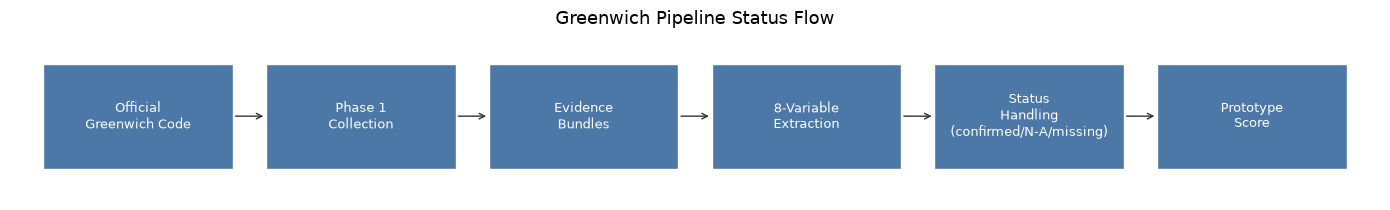

Saved: outputs/figures/greenwich_prototype_final/greenwich_pipeline_status_flow.png


In [56]:
fig, ax = plt.subplots(figsize=(14, 2.2))

pipeline_stages = [
    "Official\nGreenwich Code", "Phase 1\nCollection", "Evidence\nBundles",
    "8-Variable\nExtraction", "Status\nHandling\n(confirmed/N-A/missing)",
    "Prototype\nScore",
]

for index, stage in enumerate(pipeline_stages):
    ax.add_patch(
        plt.Rectangle((index * 2, 0), 1.7, 1, facecolor="#4C78A8", edgecolor="white")
    )
    ax.text(index * 2 + 0.85, 0.5, stage, ha="center", va="center", color="white", fontsize=9)

    if index < len(pipeline_stages) - 1:
        ax.annotate(
            "", xy=(index * 2 + 2, 0.5), xytext=(index * 2 + 1.7, 0.5),
            arrowprops={"arrowstyle": "->", "color": "#333333"},
        )

ax.set_xlim(-0.3, len(pipeline_stages) * 2)
ax.set_ylim(-0.3, 1.3)
ax.axis("off")
ax.set_title("Greenwich Pipeline Status Flow", fontsize=13)

plt.tight_layout()

pipeline_flow_path = GREENWICH_PROTOTYPE_FIGURES_DIR / "greenwich_pipeline_status_flow.png"
fig.savefig(pipeline_flow_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {pipeline_flow_path.relative_to(STAGE_A_ROOT)}")

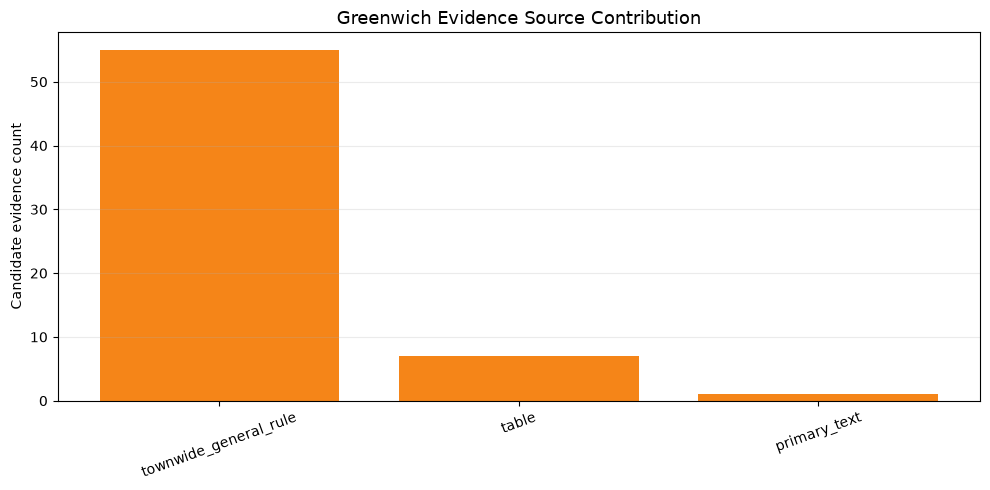

Saved: outputs/figures/greenwich_prototype_final/greenwich_evidence_source_contribution.png


In [57]:
fig, ax = plt.subplots(figsize=(10, 5))

evidence_source_counts = candidate_evidence_df["source_type"].value_counts()

ax.bar(evidence_source_counts.index, evidence_source_counts.values, color="#F58518")
ax.set_title("Greenwich Evidence Source Contribution", fontsize=13)
ax.set_ylabel("Candidate evidence count")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

source_contribution_path = GREENWICH_PROTOTYPE_FIGURES_DIR / "greenwich_evidence_source_contribution.png"
fig.savefig(source_contribution_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {source_contribution_path.relative_to(STAGE_A_ROOT)}")

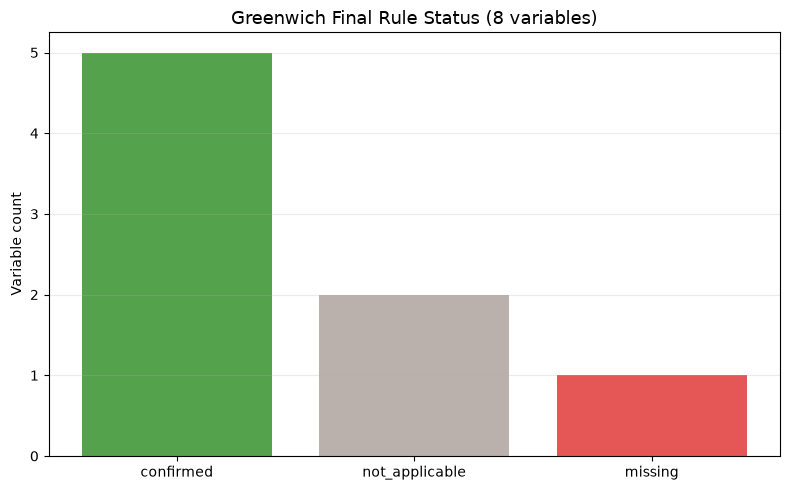

Saved: outputs/figures/greenwich_prototype_final/greenwich_rule_status_chart.png


In [58]:
fig, ax = plt.subplots(figsize=(8, 5))

final_status_counts = town_rule_extractions_df["review_status"].value_counts()
status_colors_final = {
    "confirmed": "#54A24B", "review_required": "#F2CF5B",
    "missing": "#E45756", "not_applicable": "#BAB0AC",
}

ax.bar(
    final_status_counts.index,
    final_status_counts.values,
    color=[status_colors_final.get(s, "#4C78A8") for s in final_status_counts.index],
)
ax.set_title("Greenwich Final Rule Status (8 variables)", fontsize=13)
ax.set_ylabel("Variable count")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

rule_status_path = GREENWICH_PROTOTYPE_FIGURES_DIR / "greenwich_rule_status_chart.png"
fig.savefig(rule_status_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {rule_status_path.relative_to(STAGE_A_ROOT)}")

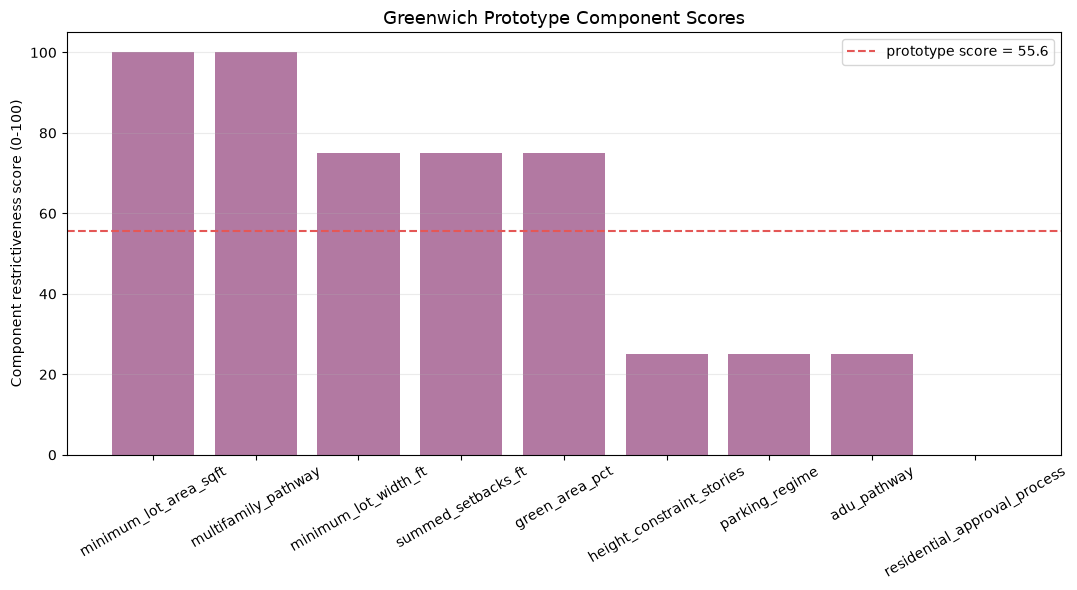

Saved: outputs/figures/greenwich_prototype_final/greenwich_prototype_component_scores.png


In [59]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_components_df = scored_components_df.sort_values("score", ascending=False)

ax.bar(plot_components_df["component"], plot_components_df["score"], color="#B279A2")
ax.axhline(
    greenwich_prototype_score, color="#E45756", linestyle="--",
    label=f"prototype score = {greenwich_prototype_score:.1f}",
)
ax.set_title("Greenwich Prototype Component Scores", fontsize=13)
ax.set_ylabel("Component restrictiveness score (0-100)")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=30)
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

component_scores_path = GREENWICH_PROTOTYPE_FIGURES_DIR / "greenwich_prototype_component_scores.png"
fig.savefig(component_scores_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {component_scores_path.relative_to(STAGE_A_ROOT)}")

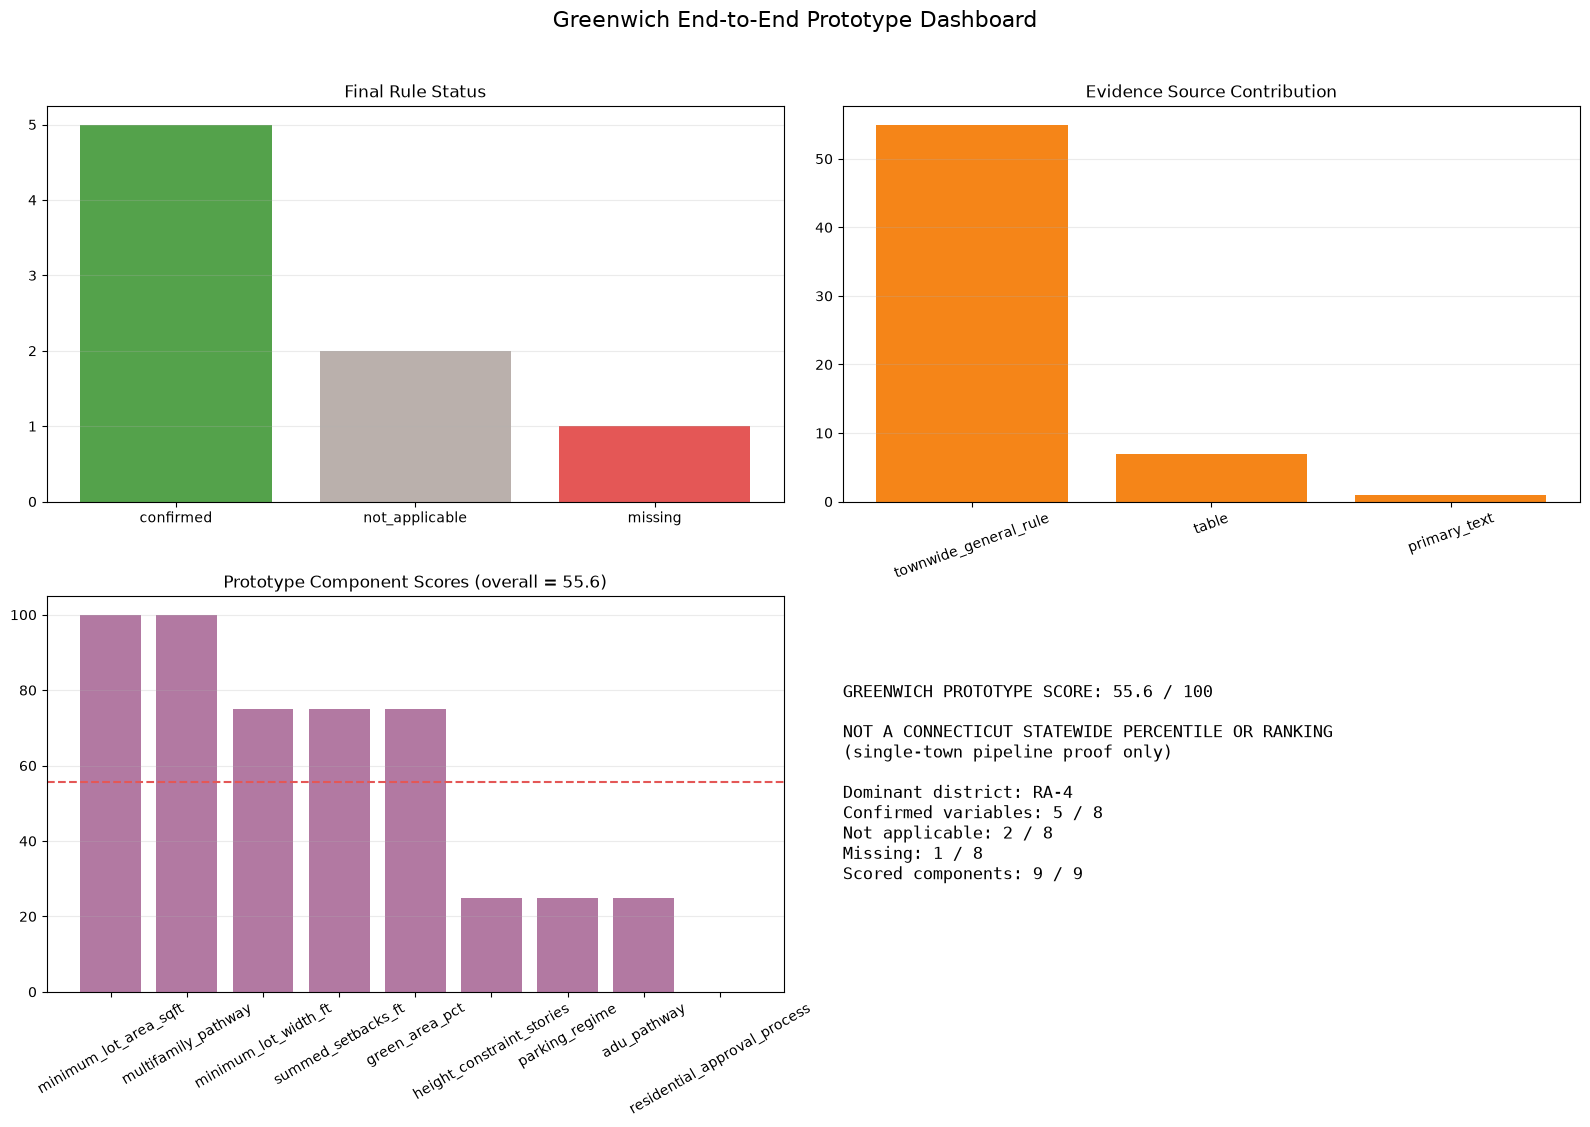

Saved: outputs/figures/greenwich_prototype_final/greenwich_end_to_end_dashboard.png
Note: the two PDF evidence-card/scorecard files from the original request were produced as PNG figures instead (above and in Section 8) to keep this notebook's dependencies minimal; ask if true PDF exports are wanted.


In [60]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].bar(
    final_status_counts.index,
    final_status_counts.values,
    color=[status_colors_final.get(s, "#4C78A8") for s in final_status_counts.index],
)
axes[0, 0].set_title("Final Rule Status")
axes[0, 0].grid(axis="y", alpha=0.25)

axes[0, 1].bar(evidence_source_counts.index, evidence_source_counts.values, color="#F58518")
axes[0, 1].set_title("Evidence Source Contribution")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].grid(axis="y", alpha=0.25)

axes[1, 0].bar(plot_components_df["component"], plot_components_df["score"], color="#B279A2")
axes[1, 0].axhline(greenwich_prototype_score, color="#E45756", linestyle="--")
axes[1, 0].set_title(f"Prototype Component Scores (overall = {greenwich_prototype_score:.1f})")
axes[1, 0].set_ylim(0, 105)
axes[1, 0].tick_params(axis="x", rotation=30)
axes[1, 0].grid(axis="y", alpha=0.25)

axes[1, 1].axis("off")
summary_text = (
    f"GREENWICH PROTOTYPE SCORE: {greenwich_prototype_score:.1f} / 100\n\n"
    "NOT A CONNECTICUT STATEWIDE PERCENTILE OR RANKING\n"
    "(single-town pipeline proof only)\n\n"
    f"Dominant district: {TARGET_DISTRICT_CODE}\n"
    f"Confirmed variables: {confirmed_count} / 8\n"
    f"Not applicable: {not_applicable_count} / 8\n"
    f"Missing: {int((town_rule_extractions_df['review_status'] == 'missing').sum())} / 8\n"
    f"Scored components: {len(scored_components_df)} / 9\n"
)
axes[1, 1].text(0.0, 0.5, summary_text, fontsize=12, va="center", family="monospace")

plt.suptitle(
    "Greenwich End-to-End Prototype Dashboard", fontsize=16, y=1.02,
)
plt.tight_layout()

dashboard_path = GREENWICH_PROTOTYPE_FIGURES_DIR / "greenwich_end_to_end_dashboard.png"
fig.savefig(dashboard_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved: {dashboard_path.relative_to(STAGE_A_ROOT)}")
print(
    "Note: the two PDF evidence-card/scorecard files from the original "
    "request were produced as PNG figures instead (above and in Section 8) "
    "to keep this notebook's dependencies minimal; ask if true PDF exports "
    "are wanted."
)

In [61]:
greenwich_prototype_manifest = {
    "town": PHASE_2_CONFIG["town"],
    "document_id": input_summary["document_id"],
    "document_hash_sha256": input_summary["document_hash_sha256"],
    "pipeline_run_timestamp": PIPELINE_RUN_TIMESTAMP,
    "dominant_district": TARGET_DISTRICT_CODE,
    "dominant_district_status": dominant_district_status,
    "confirmed_variable_count": confirmed_count,
    "not_applicable_variable_count": not_applicable_count,
    "missing_variable_count": int((town_rule_extractions_df["review_status"] == "missing").sum()),
    "review_required_variable_count": int(
        (town_rule_extractions_df["review_status"] == "review_required").sum()
    ),
    "greenwich_prototype_score": float(greenwich_prototype_score),
    "score_label": "GREENWICH PROTOTYPE SCORE -- NOT A CONNECTICUT STATEWIDE PERCENTILE OR RANKING",
    "scored_component_count": len(scored_components_df),
    "informational_component_count": int((~greenwich_prototype_components_df["scored"]).sum()),
    "statewide_scoring_status": "blocked" if not scoring_can_run else "published",
    "export_paths": {
        "evidence_profile": str(evidence_profile_path.relative_to(STAGE_A_ROOT)),
        "rule_extraction_audit": str(rule_extraction_audit_path.relative_to(STAGE_A_ROOT)),
        "score_components": str(components_path.relative_to(STAGE_A_ROOT)),
        "score_summary": str(score_summary_path.relative_to(STAGE_A_ROOT)),
        "scoring_rubric": str(rubric_path.relative_to(STAGE_A_ROOT)),
        "manual_review_history": str(manual_review_history_path.relative_to(STAGE_A_ROOT)),
        "assumptions_and_limitations": str(assumptions_path.relative_to(STAGE_A_ROOT)),
        "pipeline_status_flow_figure": str(pipeline_flow_path.relative_to(STAGE_A_ROOT)),
        "evidence_source_contribution_figure": str(source_contribution_path.relative_to(STAGE_A_ROOT)),
        "rule_status_chart_figure": str(rule_status_path.relative_to(STAGE_A_ROOT)),
        "component_scores_figure": str(component_scores_path.relative_to(STAGE_A_ROOT)),
        "dashboard_figure": str(dashboard_path.relative_to(STAGE_A_ROOT)),
    },
}

greenwich_prototype_manifest_path = LOGS_DIR / "greenwich_prototype_final_run_log.json"

with greenwich_prototype_manifest_path.open("w", encoding="utf-8") as file_handle:
    json.dump(greenwich_prototype_manifest, file_handle, indent=2, default=str)

print(f"Saved: {greenwich_prototype_manifest_path.relative_to(STAGE_A_ROOT)}")
print()
print("=" * 70)
print(f"GREENWICH PROTOTYPE SCORE: {greenwich_prototype_score:.1f} / 100")
print("NOT A CONNECTICUT STATEWIDE PERCENTILE OR RANKING")
print("=" * 70)

Saved: outputs/logs/greenwich_prototype_final_run_log.json

GREENWICH PROTOTYPE SCORE: 55.6 / 100
NOT A CONNECTICUT STATEWIDE PERCENTILE OR RANKING
